# IndMom × Quality — 行業動能 × 基本面品質選股

本筆記本採用 **Point-in-Time（PIT）資料、滾動 Walk-Forward 與一次連續的 Zipline 模擬**。
訊號在月底形成、下一個交易月執行；每個 OOS fold 的參數只由該 fold 的 IS 資料決定。

> 研究流程：產業動能篩選 → GP/A 與月營收 YoY 品質排序 → 反波動率配置 → 成本與流動性限制下的連續回測。


---
## 0｜環境與回測契約


In [ ]:
import os
import warnings
warnings.filterwarnings('default')

import pandas as pd
import numpy as np
import tejapi
import TejToolAPI
import optuna
import matplotlib.pyplot as plt
from logbook import Logger

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# ── TEJ API ──────────────────────────────────────────────────
TEJAPI_KEY  = os.environ.get('TEJAPI_KEY', 'your_own_apikey')
TEJAPI_BASE = os.environ.get('TEJAPI_BASE', 'http://tejapi.tejwin.com')

os.environ['TEJAPI_KEY']  = TEJAPI_KEY
os.environ['TEJAPI_BASE'] = TEJAPI_BASE
tejapi.ApiConfig.api_key  = TEJAPI_KEY
tejapi.ApiConfig.api_base = TEJAPI_BASE

log = Logger('IndMom_Quality')
print('環境設定完成')

環境設定完成


In [27]:
# ── 回測與資料參數 ─────────────────────────────────────────
START_DATE = '2021-01-01'   # 第一個樣本外實現月份
END_DATE   = '2026-06-30'
DATA_START = '2014-01-01'   # 因子與風險估計的暖機期

ROLL_START     = '2018-01-01'
ROLL_IS_YEARS  = 3
ROLL_OOS_YEARS = 1

TOP_IND_PCT    = 0.40
IND_MOM_MONTHS = 6
N_STOCKS       = 30
W_GPA          = 0.50
W_GROWTH       = 1.0 - W_GPA

VOL_WINDOW      = 12
MIN_VOL_OBS     = 12
MAX_FIN_AGE_DAYS = 370
MIN_PORTFOLIO_SIZE = 10
MISSING_FORWARD_RETURN = -1.0  # 月頻代理缺少精確次月價格時採最保守的全損假設

# 目標槓桿、融資成本假設與實際 gross leverage 硬上限。
LEVERAGE = 1.5
ANNUAL_FINANCING_RATE = 0.06
MAX_GROSS_LEVERAGE = 1.80
ENABLE_STOP_LOSS   = False
STOP_LOSS_PCT      = -0.10
STOP_LOSS_COOLDOWN = 3

# Optuna 採單執行緒的聯合離散搜尋，避免平行 GridSampler 重複試驗。
OPTUNA_N_TRIALS = 60
OPTUNA_N_JOBS   = 1
OPTUNA_SEED     = 20260715
TOP_IND_GRID    = [0.10, 0.20, 0.30, 0.40, 0.50]
IND_MOM_GRID    = [3, 6, 9, 12]
N_STOCKS_GRID   = [20, 30, 40, 50]
W_GPA_GRID      = [0.30, 0.50, 0.70]

# 簡化選參代理的交易成本：券商費率 0.1425% × 6 折；賣出另含 0.3% 證交稅。
PROXY_BUY_COST_RATE  = 0.001425 * 0.6
PROXY_SELL_COST_RATE = PROXY_BUY_COST_RATE + 0.003

VOLUME_LIMIT = 0.025
PRICE_IMPACT = 0.10
CAPITAL_BASE = 10_000_000

print(f'樣本外期間：{START_DATE} ~ {END_DATE}')
print(f'基準設定：產業前 {TOP_IND_PCT:.0%}、持有 {N_STOCKS} 檔、槓桿 {LEVERAGE:.1f}x')


樣本外期間：2021-01-01 ~ 2026-06-30
基準設定：產業前 40%、持有 30 檔、槓桿 1.5x


---
## 1｜Data Contract 與資料驗證

| 研究變數 | TEJ 資料表 | 請求欄位 | 回傳欄名 | 頻率 | 備註 |
|---------|-----------|---------|---------|------|------|
| 個股月報酬 | TWN/APIPRCD | `roi` | `ROI` | 日（取月底） | 用於計算行業動能 |
| 個股市值 | TWN/APIPRCD | `mktcap` | `Market_Cap_Dollars` | 日（取月底） | 行業報酬市值加權 |
| 行業別 | TWN/APISTKATTR | `main_ind_c` | `Industry` | 日（取月底） | TEJ 主產業別 |
| 證券種類 | TWN/APISTKATTR | `stktp_e` | `Security_Type_English` | 日 | 排除 ETF、特別股 |
| 全額交割/注意/處置 | TWN/APISTKATTR | `full_fg`,`atten_fg`,`disp_fg` | `Full_Delivery_Stock_Fg`,`Attention_Stock_Fg`,`Disposition_Stock_Fg` | 日 | 流動性濾網 |
| 毛利（GP） | TWN/AINVFINB | `a3295` | `Gross_Profit_Loss_From_Operations` | 季 | Novy-Marx GP/A 分子 |
| 總資產（A） | TWN/AINVFINB | `a0010` | `Total_Assets` | 季 | Novy-Marx GP/A 分母 |
| 月營收成長率 | TWN/APISALE1 | `d0003` | `YoY_Monthly_Sales` | 月 | 次月 10 日前公告 |

---
## 2｜股票池

In [28]:
from zipline.sources.TEJ_Api_Data import get_universe

# 這裡只用聯集縮小 API 查詢範圍；真正的 TSE／普通股資格會在每個月底重新判斷。
pool = get_universe(
    start=pd.Timestamp(DATA_START, tz='UTC'),
    end=pd.Timestamp(END_DATE, tz='UTC'),
    mkt_bd_e=['TSE'],
    stktp_e='Common Stock',
)
pool = sorted({str(t) for t in pool})
if not pool:
    raise RuntimeError('TEJ 股票池為空，請檢查 API 權限與日期。')
print(f'API 查詢聯集：{len(pool):,} 檔；月底會再套用 PIT 股票池。')


Currently used TEJ API key call quota 1508/100000 (1.51%)
Currently used TEJ API key data quota 170345401/10000000 (1703.45%)
API 查詢聯集：1,022 檔；月底會再套用 PIT 股票池。


---
## 3｜資料下載

In [29]:
# ── 3-A  日行情：日報酬與市值 ───────────────────────────────
price_raw = TejToolAPI.get_history_data(
    ticker=pool,
    columns=['roi', 'mktcap'],
    start=DATA_START,
    end=END_DATE,
    transfer_to_chinese=False,
)
print('[price_raw] columns:', price_raw.columns.tolist())
print('[price_raw] shape  :', price_raw.shape)
price_raw.head(3)


Currently used TEJ API key call quota 1574/100000 (1.57%)
Currently used TEJ API key data quota 178733589/10000000 (1787.34%)
[price_raw] columns: ['coid', 'mdate', 'Market_Cap_Dollars', 'ROI']
[price_raw] shape  : (2676339, 4)


,coid,mdate,Market_Cap_Dollars,ROI
0,1101,2014-01-02,1.676248e+11,-1.8378
1,1101,2014-01-03,1.644864e+11,-1.8722
2,1101,2014-01-06,1.609789e+11,-2.1324


In [30]:
# ── 3-B  PIT 市場別、證券類型、產業與交易警示旗標 ───────────
attr_raw = TejToolAPI.get_history_data(
    ticker=pool,
    columns=['main_ind_c', 'mkt_bd_e', 'stktp_e', 'full_fg', 'atten_fg', 'disp_fg'],
    start=DATA_START,
    end=END_DATE,
    transfer_to_chinese=False,
)
print('[attr_raw] columns:', attr_raw.columns.tolist())
print('[attr_raw] shape  :', attr_raw.shape)
attr_raw.head(3)


Currently used TEJ API key call quota 1640/100000 (1.64%)
Currently used TEJ API key data quota 187121777/10000000 (1871.22%)
[attr_raw] columns: ['coid', 'mdate', 'Market_Board_Eng', 'Industry', 'Attention_Stock_Fg', 'Security_Type_English', 'Full_Delivery_Stock_Fg', 'Disposition_Stock_Fg']
[attr_raw] shape  : (2676339, 8)


,coid,mdate,Market_Board_Eng,Industry,Attention_Stock_Fg,Security_Type_English,Full_Delivery_Stock_Fg,Disposition_Stock_Fg
0,1101,2014-01-02,TSE,M1100 水泥工業,,Common Stock,,
1,1101,2014-01-03,TSE,M1100 水泥工業,,Common Stock,,
2,1101,2014-01-06,TSE,M1100 水泥工業,,Common Stock,,


In [31]:
# ── 3-C  財報：TejToolAPI 會依實際公告日對齊至交易日 ─────────
fin_raw = TejToolAPI.get_history_data(
    ticker=pool,
    columns=['a3295', 'a0010'],
    fin_type=['Q', 'TTM'],
    include_self_acc='N',
    start=DATA_START,
    end=END_DATE,
    require_annd=True,
    transfer_to_chinese=False,
)
print('[fin_raw] columns:', fin_raw.columns.tolist())
print('[fin_raw] shape  :', fin_raw.shape)
fin_raw.head(3)


Currently used TEJ API key call quota 1706/100000 (1.71%)
Currently used TEJ API key data quota 190318573/10000000 (1903.19%)
[fin_raw] columns: ['coid', 'mdate', 'Total_Assets_Q', 'fin_date', 'Gross_Profit_Loss_From_Operations_Q', 'Gross_Profit_Loss_From_Operations_TTM', 'Total_Assets_TTM']
[fin_raw] shape  : (2676339, 7)


,coid,mdate,Total_Assets_Q,fin_date,Gross_Profit_Loss_From_Operations_Q,Gross_Profit_Loss_From_Operations_TTM,Total_Assets_TTM
0,1101,2014-01-02,271992941.0,2013-09-01,7054489.0,NaN,NaN
1,1101,2014-01-03,271992941.0,2013-09-01,7054489.0,NaN,NaN
2,1101,2014-01-06,271992941.0,2013-09-01,7054489.0,NaN,NaN


In [32]:
# ── 3-D  月營收原始公告資料：同時保留營收月份 mdate 與公告日 annd_s ─
# TejToolAPI 的 mon_sales_date 是公告日，不是營收所屬月份；因此此處直接查原表。
rev_raw = tejapi.fastget(
    'TWN/APISALE1',
    coid=pool,
    mdate={'gte': DATA_START, 'lte': END_DATE},
    paginate=True,
    chinese_column_name=False,
    opts={'columns': ['coid', 'mdate', 'annd_s', 'd0003', 'key3']},
)
print('[rev_raw] columns:', rev_raw.columns.tolist())
print('[rev_raw] shape  :', rev_raw.shape)
rev_raw.head(3)


[rev_raw] columns: ['coid', 'mdate', 'annd_s', 'd0003', 'key3']
[rev_raw] shape  : (133879, 5)


,coid,mdate,annd_s,d0003,key3
0,1101,2014-01-01,2014-02-10,7.30,1.0
1,1101,2014-02-01,2014-03-10,9.88,1.0
2,1101,2014-03-01,2014-04-10,14.56,1.0


---
## 4｜資料前處理

In [33]:
# ── 4-A  日行情轉月資料；保留真實最後交易日 ─────────────────
required_price = {'coid', 'mdate', 'ROI', 'Market_Cap_Dollars'}
missing = required_price.difference(price_raw.columns)
if missing:
    raise KeyError(f'price_raw 缺少欄位：{sorted(missing)}')

price_raw = price_raw.copy()
price_raw['coid'] = price_raw['coid'].astype(str)
price_raw['mdate'] = pd.to_datetime(price_raw['mdate']).dt.tz_localize(None)
price_raw['ROI'] = pd.to_numeric(price_raw['ROI'], errors='coerce')
price_raw['Market_Cap_Dollars'] = pd.to_numeric(
    price_raw['Market_Cap_Dollars'], errors='coerce'
)
price_raw = price_raw.dropna(subset=['coid', 'mdate']).sort_values(['coid', 'mdate'])
if price_raw.duplicated(['coid', 'mdate']).any():
    duplicate_count = int(price_raw.duplicated(['coid', 'mdate'], keep=False).sum())
    raise RuntimeError(f'price_raw 有 {duplicate_count} 筆重複的 coid×mdate，禁止重複複利。')
price_raw['month_end'] = price_raw['mdate'] + pd.offsets.MonthEnd(0)
price_raw['r1'] = 1.0 + price_raw['ROI'] / 100.0

market_month_end = (
    price_raw.groupby('month_end', as_index=False)['mdate']
    .max()
    .rename(columns={'month_end': 'mdate', 'mdate': 'market_last_date'})
)

monthly_ret = (
    price_raw.groupby(['coid', 'month_end'])['r1']
    .agg(lambda s: s.prod(min_count=1))
    .sub(1.0).mul(100.0)
    .rename('ROI').reset_index()
    .rename(columns={'month_end': 'mdate'})
)
monthly_state = (
    price_raw.sort_values(['coid', 'mdate'])
    .groupby(['coid', 'month_end'], as_index=False, group_keys=False)
    .tail(1)
    [['coid', 'month_end', 'mdate', 'Market_Cap_Dollars']]
    .rename(columns={'month_end': 'month_label', 'mdate': 'last_obs_date'})
    .rename(columns={'month_label': 'mdate'})
)
monthly_counts = (
    price_raw.groupby(['coid', 'month_end'])['ROI']
    .count().rename('n_daily_returns').reset_index()
    .rename(columns={'month_end': 'mdate'})
)
monthly_state = monthly_state.merge(
    monthly_counts, on=['coid', 'mdate'], how='left', validate='one_to_one'
)
price_monthly = monthly_ret.merge(monthly_state, on=['coid', 'mdate'], how='outer')

# 價值加權產業報酬使用「前一個曆月底」市值，不能用動能期末市值。
lagged_cap = price_monthly[['coid', 'mdate', 'Market_Cap_Dollars']].copy()
lagged_cap['mdate'] = lagged_cap['mdate'] + pd.offsets.MonthEnd(1)
lagged_cap = lagged_cap.rename(columns={'Market_Cap_Dollars': 'Lagged_Market_Cap'})
price_monthly = price_monthly.merge(lagged_cap, on=['coid', 'mdate'], how='left')
price_monthly = price_monthly.sort_values(['mdate', 'coid']).reset_index(drop=True)

if price_monthly.duplicated(['coid', 'mdate']).any():
    raise RuntimeError('price_monthly 出現重複的 coid×mdate。')
print('月行情筆數：', price_monthly.shape)
print('市場月份：', price_monthly['mdate'].min().date(), '~', price_monthly['mdate'].max().date())
price_monthly.head(3)


月行情筆數： (131967, 7)
市場月份： 2014-01-31 ~ 2026-06-30


,coid,mdate,ROI,last_obs_date,Market_Cap_Dollars,n_daily_returns,Lagged_Market_Cap
0,1101,2014-01-31,-4.215993,2014-01-27,1.635634e+11,18,NaN
1,1102,2014-01-31,-3.367753,2014-01-27,1.229235e+11,18,NaN
2,1103,2014-01-31,-1.273984,2014-01-27,1.204084e+10,18,NaN


In [34]:
# ── 4-B  每月底重新套用 TSE 普通股與交易警示濾網 ─────────────
required_attr = {
    'coid', 'mdate', 'Industry', 'Market_Board_Eng', 'Security_Type_English',
    'Full_Delivery_Stock_Fg', 'Attention_Stock_Fg', 'Disposition_Stock_Fg',
}
missing = required_attr.difference(attr_raw.columns)
if missing:
    raise KeyError(f'attr_raw 缺少欄位：{sorted(missing)}')

attr_raw = attr_raw.copy()
attr_raw['coid'] = attr_raw['coid'].astype(str)
attr_raw['mdate'] = pd.to_datetime(attr_raw['mdate']).dt.tz_localize(None)
attr_raw['month_end'] = attr_raw['mdate'] + pd.offsets.MonthEnd(0)
attr_monthly = (
    attr_raw.sort_values(['coid', 'mdate'])
    .groupby(['coid', 'month_end'], as_index=False, group_keys=False)
    .tail(1)
    .rename(columns={'mdate': 'last_obs_date', 'month_end': 'mdate'})
    .merge(market_month_end, on='mdate', how='left', validate='many_to_one')
)

_FLAG_TRUE = {'Y', 'YES', '1', 'TRUE', 'T'}
_FLAG_FALSE = {'N', 'NO', '0', 'FALSE', 'F', ''}

def flag_is_true(series, field_name):
    normalized = series.astype('string').str.strip().str.upper()
    unknown = sorted(set(normalized.dropna().unique()) - _FLAG_TRUE - _FLAG_FALSE)
    if unknown:
        raise ValueError(f'{field_name} 出現未知旗標值：{unknown}')
    return normalized.isin(_FLAG_TRUE)

flag_fields = [
    'Full_Delivery_Stock_Fg',
    'Attention_Stock_Fg',
    'Disposition_Stock_Fg',
]
for field in flag_fields:
    values = sorted(attr_monthly[field].dropna().astype(str).str.strip().unique().tolist())
    print(f'{field} values:', values, '| NA:', int(attr_monthly[field].isna().sum()))

active_at_month_end = attr_monthly['last_obs_date'].eq(attr_monthly['market_last_date'])
tradable_mask = (
    attr_monthly['Market_Board_Eng'].astype('string').str.strip().eq('TSE')
    & attr_monthly['Security_Type_English'].astype('string').str.strip().eq('Common Stock')
    & attr_monthly['Industry'].notna()
    & attr_monthly['Industry'].astype(str).str.strip().ne('')
    & active_at_month_end
    & ~flag_is_true(attr_monthly['Full_Delivery_Stock_Fg'], 'Full_Delivery_Stock_Fg')
    & ~flag_is_true(attr_monthly['Attention_Stock_Fg'], 'Attention_Stock_Fg')
    & ~flag_is_true(attr_monthly['Disposition_Stock_Fg'], 'Disposition_Stock_Fg')
)
excluded_count = int((~tradable_mask).sum())
attr_monthly = attr_monthly.loc[tradable_mask].copy()
attr_monthly = attr_monthly.sort_values(['mdate', 'coid']).reset_index(drop=True)

if attr_monthly.duplicated(['coid', 'mdate']).any():
    raise RuntimeError('attr_monthly 出現重複的 coid×mdate。')
universe_count = attr_monthly.groupby('mdate')['coid'].nunique()
print(f'PIT 濾網排除 {excluded_count:,} 筆股票月份。')
print('月底可投資股票數（min/median/max）：',
      int(universe_count.min()), int(universe_count.median()), int(universe_count.max()))
attr_monthly.head(3)


Full_Delivery_Stock_Fg values: ['', 'Y'] | NA: 0
Attention_Stock_Fg values: ['', 'Y'] | NA: 0
Disposition_Stock_Fg values: ['', 'Y'] | NA: 0
PIT 濾網排除 4,434 筆股票月份。
月底可投資股票數（min/median/max）： 802 837 930


,coid,last_obs_date,Market_Board_Eng,Industry,Attention_Stock_Fg,Security_Type_English,Full_Delivery_Stock_Fg,Disposition_Stock_Fg,mdate,market_last_date
0,1101,2014-01-27,TSE,M1100 水泥工業,,Common Stock,,,2014-01-31,2014-01-27
1,1102,2014-01-27,TSE,M1100 水泥工業,,Common Stock,,,2014-01-31,2014-01-27
2,1103,2014-01-27,TSE,M1100 水泥工業,,Common Stock,,,2014-01-31,2014-01-27


In [35]:
# ── 4-C  財報已由 TejToolAPI 依實際公告日做 PIT 對齊 ──────────
required_fin = {
    'coid', 'mdate', 'fin_date',
    'Gross_Profit_Loss_From_Operations_TTM', 'Total_Assets_Q',
}
missing = required_fin.difference(fin_raw.columns)
if missing:
    raise KeyError(f'fin_raw 缺少欄位：{sorted(missing)}')

fin_raw = fin_raw.copy()
fin_raw['coid'] = fin_raw['coid'].astype(str)
fin_raw['mdate'] = pd.to_datetime(fin_raw['mdate']).dt.tz_localize(None)
fin_raw['fin_date'] = pd.to_datetime(fin_raw['fin_date']).dt.tz_localize(None)
fin_raw['Gross_Profit_Loss_From_Operations_TTM'] = pd.to_numeric(
    fin_raw['Gross_Profit_Loss_From_Operations_TTM'], errors='coerce'
)
fin_raw['Total_Assets_Q'] = pd.to_numeric(fin_raw['Total_Assets_Q'], errors='coerce')
fin_raw['GP_A'] = np.where(
    fin_raw['Total_Assets_Q'] > 0,
    fin_raw['Gross_Profit_Loss_From_Operations_TTM'] / fin_raw['Total_Assets_Q'],
    np.nan,
)
fin_raw['GP_A'] = fin_raw['GP_A'].replace([np.inf, -np.inf], np.nan)
fin_raw['month_end'] = fin_raw['mdate'] + pd.offsets.MonthEnd(0)

# tail(1) 保留同一列的 fin_date 與 GP_A，避免 groupby.last 混合不同列。
fin_monthly = (
    fin_raw.sort_values(['coid', 'mdate'])
    .groupby(['coid', 'month_end'], as_index=False, group_keys=False)
    .tail(1)
    .rename(columns={'month_end': 'mdate', 'mdate': 'last_obs_date'})
    [['coid', 'mdate', 'fin_date', 'GP_A']]
)
fin_monthly['fin_age_days'] = (fin_monthly['mdate'] - fin_monthly['fin_date']).dt.days
stale_fin_count = int((
    fin_monthly['GP_A'].notna() & fin_monthly['fin_age_days'].gt(MAX_FIN_AGE_DAYS)
).sum())
valid_fin = (
    fin_monthly['GP_A'].notna()
    & fin_monthly['fin_age_days'].between(0, MAX_FIN_AGE_DAYS, inclusive='both')
)
fin_monthly = fin_monthly.loc[valid_fin].copy()
print('PIT 財報月資料：', fin_monthly.shape)
print(f'因財報超過 {MAX_FIN_AGE_DAYS} 天而排除：{stale_fin_count:,} 筆股票月份')
print('財報期末日至訊號月底天數分位數：')
print(fin_monthly['fin_age_days'].quantile([0.0, 0.5, 0.9, 1.0]).round(1))


PIT 財報月資料： (124985, 5)
因財報超過 370 天而排除：7 筆股票月份
財報期末日至訊號月底天數分位數：
0.0     60.0
0.5    121.0
0.9    152.0
1.0    365.0
Name: fin_age_days, dtype: float64


In [36]:
# ── 4-D  GP/A 資料契約檢查 ─────────────────────────────────
fin_clean = fin_monthly[['coid', 'mdate', 'fin_date', 'fin_age_days', 'GP_A']].copy()
fin_clean = fin_clean.replace([np.inf, -np.inf], np.nan).dropna(subset=['GP_A'])
if fin_clean.duplicated(['coid', 'mdate']).any():
    raise RuntimeError('fin_clean 出現重複的 coid×mdate。')
if not np.isfinite(fin_clean['GP_A']).all():
    raise RuntimeError('GP/A 仍含非有限值。')
print(f'可用 GP/A 股票月份：{len(fin_clean):,}')
fin_clean.head(3)


可用 GP/A 股票月份：124,985


,coid,mdate,fin_date,fin_age_days,GP_A
55,1101,2014-03-31,2013-12-01,120.0,0.080738
76,1101,2014-04-30,2013-12-01,150.0,0.080738
97,1101,2014-05-31,2014-03-01,91.0,0.085957


In [37]:
# ── 4-E  月營收公告表：保留真正營收月份與公告日 ──────────────
required_rev = {'coid', 'mdate', 'annd_s', 'd0003', 'key3'}
missing = required_rev.difference(rev_raw.columns)
if missing:
    raise KeyError(f'rev_raw 缺少欄位：{sorted(missing)}')

rev_announced = rev_raw[list(required_rev)].copy()
rev_announced['coid'] = rev_announced['coid'].astype(str)
rev_announced['revenue_month'] = (
    pd.to_datetime(rev_announced['mdate']).dt.tz_localize(None) + pd.offsets.MonthEnd(0)
)
rev_announced['announcement_date'] = pd.to_datetime(
    rev_announced['annd_s']
).dt.tz_localize(None)
rev_announced['rev_yoy_lagged'] = pd.to_numeric(
    rev_announced['d0003'], errors='coerce'
)
rev_announced['key3'] = rev_announced['key3'].astype('string').fillna('')
rev_announced = rev_announced.dropna(
    subset=['revenue_month', 'announcement_date', 'rev_yoy_lagged']
)
rev_announced = (
    rev_announced.sort_values(
        ['coid', 'revenue_month', 'announcement_date', 'key3']
    )
    .drop_duplicates(
        ['coid', 'revenue_month', 'announcement_date', 'key3'], keep='last'
    )
    [['coid', 'revenue_month', 'announcement_date', 'key3', 'rev_yoy_lagged']]
    .reset_index(drop=True)
)
impossible = rev_announced['announcement_date'] < rev_announced['revenue_month'] - pd.offsets.MonthEnd(1)
if impossible.any():
    raise RuntimeError(f'發現 {int(impossible.sum())} 筆公告日早於合理營收月份的資料。')
print(f'原始月營收公告：{len(rev_announced):,} 筆、{rev_announced.coid.nunique():,} 檔。')
print('公告延遲天數分位數：')
print((rev_announced['announcement_date'] - rev_announced['revenue_month']).dt.days
      .quantile([0.0, 0.5, 0.9, 1.0]).round(1))
rev_announced.head(3)


原始月營收公告：133,541 筆、1,021 檔。
公告延遲天數分位數：
0.0       1.0
0.5       9.0
0.9      10.0
1.0    3123.0
dtype: float64


,coid,revenue_month,announcement_date,key3,rev_yoy_lagged
0,1101,2014-01-31,2014-02-10,1.0,7.30
1,1101,2014-02-28,2014-03-10,1.0,9.88
2,1101,2014-03-31,2014-04-10,1.0,14.56


---
## 5｜`compute_stock`：每期選股邏輯

In [38]:
_signal_snapshot_cache = {}

def get_latest_fin(coid_list, as_of_date, fin_df):
    """取得訊號月底已公告且通過資料年齡檢查的 PIT 財報值。"""
    signal_date = pd.Timestamp(as_of_date) + pd.offsets.MonthEnd(0)
    return fin_df[
        fin_df['coid'].isin(coid_list) & fin_df['mdate'].eq(signal_date)
    ][['coid', 'GP_A']].copy()


def get_latest_revenue(coid_list, as_of_date, rev_df):
    """取得訊號月底前已公告、營收所屬月份恰為 T-1 的最後版本。"""
    signal_date = pd.Timestamp(as_of_date) + pd.offsets.MonthEnd(0)
    expected_revenue_month = signal_date - pd.offsets.MonthEnd(1)
    eligible = rev_df.loc[
        rev_df['coid'].isin(coid_list)
        & rev_df['revenue_month'].eq(expected_revenue_month)
        & rev_df['announcement_date'].le(signal_date)
    ].copy()
    return (
        eligible.sort_values(['coid', 'announcement_date', 'key3'])
        .groupby('coid', as_index=False, group_keys=False)
        .tail(1)
        [['coid', 'rev_yoy_lagged']]
    )


def _build_signal_snapshot(signal_date, price_df, attr_df, fin_df, rev_df, ind_mom_months):
    """建立某個訊號月底與動能窗格的 PIT 因子快照；昂貴運算會快取。"""
    signal_date = pd.Timestamp(signal_date) + pd.offsets.MonthEnd(0)
    cache_key = (signal_date, int(ind_mom_months))
    if cache_key in _signal_snapshot_cache:
        return _signal_snapshot_cache[cache_key]

    attr_t = attr_df.loc[attr_df['mdate'].eq(signal_date), ['coid', 'Industry']].copy()
    if attr_t.empty:
        snapshot = pd.DataFrame()
        _signal_snapshot_cache[cache_key] = snapshot
        return snapshot

    dates_window = pd.date_range(end=signal_date, periods=ind_mom_months, freq='ME')
    price_window = price_df.loc[
        price_df['mdate'].isin(dates_window),
        ['coid', 'mdate', 'ROI', 'Lagged_Market_Cap'],
    ].copy()
    # t 月產業報酬只能使用 t-1 月底已知的成分資格與產業別。
    prior_attr_dates = dates_window - pd.offsets.MonthEnd(1)
    attr_history = attr_df.loc[
        attr_df['mdate'].isin(prior_attr_dates), ['coid', 'mdate', 'Industry']
    ].copy()
    attr_history['mdate'] = attr_history['mdate'] + pd.offsets.MonthEnd(1)
    price_window = price_window.merge(
        attr_history, on=['coid', 'mdate'], how='inner', validate='one_to_one'
    )
    valid = (
        np.isfinite(price_window['ROI'])
        & np.isfinite(price_window['Lagged_Market_Cap'])
        & price_window['Lagged_Market_Cap'].gt(0)
    )
    price_window = price_window.loc[valid].copy()
    price_window['weighted_return'] = (
        price_window['ROI'].div(100.0) * price_window['Lagged_Market_Cap']
    )
    ind_monthly = (
        price_window.groupby(['Industry', 'mdate'], as_index=False)
        .agg(
            weighted_return=('weighted_return', 'sum'),
            total_weight=('Lagged_Market_Cap', 'sum'),
            n_constituents=('coid', 'nunique'),
        )
    )
    ind_monthly['industry_return'] = (
        ind_monthly['weighted_return'] / ind_monthly['total_weight']
    )
    ind_mom = (
        ind_monthly.groupby('Industry', as_index=False)
        .agg(
            n_months=('mdate', 'nunique'),
            ind_mom=('industry_return', lambda s: (1.0 + s).prod(min_count=1) - 1.0),
        )
    )
    ind_mom = ind_mom.loc[
        ind_mom['n_months'].eq(ind_mom_months) & np.isfinite(ind_mom['ind_mom'])
    ]

    candidates = attr_t.merge(ind_mom[['Industry', 'ind_mom']], on='Industry', how='inner')
    current_price = price_df.loc[
        price_df['mdate'].eq(signal_date), ['coid', 'Market_Cap_Dollars']
    ]
    candidates = candidates.merge(current_price, on='coid', how='inner', validate='one_to_one')
    candidates = candidates.loc[
        np.isfinite(candidates['Market_Cap_Dollars']) & candidates['Market_Cap_Dollars'].gt(0)
    ]
    candidates = candidates.merge(
        get_latest_fin(candidates['coid'].tolist(), signal_date, fin_df),
        on='coid', how='inner', validate='one_to_one',
    )
    rev_t = get_latest_revenue(candidates['coid'].tolist(), signal_date, rev_df)
    candidates = candidates.merge(rev_t, on='coid', how='inner', validate='one_to_one')

    vol_dates = pd.date_range(end=signal_date, periods=VOL_WINDOW, freq='ME')
    vol_stats = (
        price_df.loc[price_df['mdate'].isin(vol_dates), ['coid', 'mdate', 'ROI']]
        .dropna(subset=['ROI'])
        .groupby('coid', as_index=False)
        .agg(vol_obs=('mdate', 'nunique'), volatility=('ROI', lambda s: s.std(ddof=1)))
    )
    vol_stats['volatility'] = vol_stats['volatility'] / 100.0
    candidates = candidates.merge(vol_stats, on='coid', how='inner', validate='one_to_one')
    candidates = candidates.loc[
        candidates['vol_obs'].ge(MIN_VOL_OBS)
        & np.isfinite(candidates['volatility'])
        & candidates['volatility'].gt(0)
        & np.isfinite(candidates['GP_A'])
        & np.isfinite(candidates['rev_yoy_lagged'])
    ].copy()

    snapshot = candidates.drop_duplicates('coid').reset_index(drop=True)
    _signal_snapshot_cache[cache_key] = snapshot
    return snapshot


def compute_stock(signal_date, price_df, attr_df, fin_df, rev_df,
                  top_ind_pct=TOP_IND_PCT,
                  ind_mom_months=IND_MOM_MONTHS,
                  n_stocks=N_STOCKS,
                  w_gpa=W_GPA,
                  w_growth=None):
    """依 PIT 產業動能與品質因子選股，缺任一因子者不給中性分數。"""
    if w_growth is None:
        w_growth = 1.0 - w_gpa
    if not np.isclose(w_gpa + w_growth, 1.0):
        raise ValueError('w_gpa + w_growth 必須等於 1。')

    snapshot = _build_signal_snapshot(
        signal_date, price_df, attr_df, fin_df, rev_df, ind_mom_months
    )
    if snapshot.empty:
        return []

    industry_ranking = (
        snapshot[['Industry', 'ind_mom']].drop_duplicates()
        .sort_values(['ind_mom', 'Industry'], ascending=[False, True])
    )
    n_top = max(1, int(np.ceil(len(industry_ranking) * float(top_ind_pct))))
    top_industries = industry_ranking.head(n_top)['Industry']
    factors = snapshot.loc[snapshot['Industry'].isin(top_industries)].copy()
    if factors.empty:
        return []

    factors['gpa_rank'] = factors['GP_A'].rank(pct=True, method='average')
    factors['growth_rank'] = factors['rev_yoy_lagged'].rank(pct=True, method='average')
    factors['quality_score'] = (
        float(w_gpa) * factors['gpa_rank'] + float(w_growth) * factors['growth_rank']
    )
    selected = factors.sort_values(
        ['quality_score', 'GP_A', 'rev_yoy_lagged', 'coid'],
        ascending=[False, False, False, True],
    ).head(int(n_stocks))
    return selected['coid'].astype(str).tolist()


print('PIT 選股函數建立完成。')


PIT 選股函數建立完成。


---
## 6｜參數掃描：TOP_IND_PCT 10%～50%（僅 In-sample，避免前視偏誤）

In [39]:
# ── 6｜成本感知的月頻選參代理（不含日內滑價與停損）────────────
roi_lookup = price_monthly[['coid', 'mdate', 'ROI']].copy()
roi_lookup = roi_lookup.rename(columns={'mdate': 'realized_date', 'ROI': 'next_ROI'})
roi_lookup['signal_date'] = roi_lookup['realized_date'] - pd.offsets.MonthEnd(1)
if roi_lookup.duplicated(['coid', 'signal_date']).any():
    raise RuntimeError('roi_lookup 出現重複的 coid×signal_date。')


def compute_vol_weights(picks, signal_date, price_df):
    picks = list(dict.fromkeys(map(str, picks)))
    if not picks:
        return {}
    signal_date = pd.Timestamp(signal_date) + pd.offsets.MonthEnd(0)
    dates = pd.date_range(end=signal_date, periods=VOL_WINDOW, freq='ME')
    stats = (
        price_df.loc[
            price_df['coid'].isin(picks) & price_df['mdate'].isin(dates),
            ['coid', 'mdate', 'ROI'],
        ]
        .dropna(subset=['ROI'])
        .groupby('coid')
        .agg(obs=('mdate', 'nunique'), vol=('ROI', lambda s: s.std(ddof=1) / 100.0))
    )
    stats = stats.loc[
        stats['obs'].ge(MIN_VOL_OBS) & np.isfinite(stats['vol']) & stats['vol'].gt(0)
    ]
    missing_picks = sorted(set(picks) - set(stats.index))
    if missing_picks:
        raise RuntimeError(
            f'{signal_date.date()} 有 {len(missing_picks)} 檔入選股缺少完整波動率窗格：'
            f'{missing_picks[:8]}'
        )
    inv_vol = 1.0 / stats['vol']
    weights = inv_vol / inv_vol.sum()
    return weights.reindex(picks).to_dict()


def simple_backtest(selection_by_signal, roi_table, price_df,
                    leverage=LEVERAGE, return_diagnostics=False):
    """訊號月底決定權重，報酬記在下一個實現月份；不依未來有無報酬刪股。"""
    return_map = roi_table.set_index(['signal_date', 'coid'])['next_ROI']
    prev_weights = {}
    records, diagnostics = [], []

    for signal_date, picks in sorted(selection_by_signal.items()):
        signal_date = pd.Timestamp(signal_date) + pd.offsets.MonthEnd(0)
        base_weights = compute_vol_weights(picks, signal_date, price_df) if picks else {}
        target_weights = {ticker: weight * leverage for ticker, weight in base_weights.items()}
        all_symbols = set(prev_weights) | set(target_weights)
        buys = sum(max(target_weights.get(t, 0.0) - prev_weights.get(t, 0.0), 0.0)
                   for t in all_symbols)
        sells = sum(max(prev_weights.get(t, 0.0) - target_weights.get(t, 0.0), 0.0)
                    for t in all_symbols)
        cost = buys * PROXY_BUY_COST_RATE + sells * PROXY_SELL_COST_RATE
        monthly_financing_rate = (1.0 + ANNUAL_FINANCING_RATE) ** (1.0 / 12.0) - 1.0
        borrowed_exposure = max(sum(abs(w) for w in target_weights.values()) - 1.0, 0.0)
        financing_cost = borrowed_exposure * monthly_financing_rate

        missing_forward = []
        gross_return = 0.0
        realized_stock_returns = {}
        for ticker, weight in target_weights.items():
            value = return_map.get((signal_date, ticker), np.nan)
            if pd.isna(value):
                # 無正式下市報酬時採全損，避免把下市／長停牌誤當保本。
                stock_return = MISSING_FORWARD_RETURN
                missing_forward.append(ticker)
            else:
                stock_return = float(value) / 100.0
            realized_stock_returns[ticker] = stock_return
            gross_return += weight * stock_return

        realized_date = signal_date + pd.offsets.MonthEnd(1)
        net_return = gross_return - cost - financing_cost
        records.append((realized_date, net_return))
        diagnostics.append({
            'signal_date': signal_date,
            'realized_date': realized_date,
            'n_picks': len(target_weights),
            'missing_forward_returns': len(missing_forward),
            'missing_forward_weight': sum(target_weights[t] for t in missing_forward),
            'buy_turnover': buys,
            'sell_turnover': sells,
            'proxy_cost': cost,
            'financing_cost': financing_cost,
            'borrowed_exposure': borrowed_exposure,
        })
        # 下一次換倉要和「報酬漂移後」的持倉權重比較，不能沿用上期目標權重。
        ending_equity = 1.0 + net_return
        prev_weights = (
            {
                ticker: weight * (1.0 + realized_stock_returns[ticker]) / ending_equity
                for ticker, weight in target_weights.items()
                if weight != 0 and realized_stock_returns[ticker] > -1.0
            }
            if ending_equity > 0 else {}
        )

    result = pd.Series(dict(records), name='strategy_return', dtype=float).sort_index()
    if len(result) != len(records):
        raise RuntimeError('simple_backtest 的 realized_date 發生重複。')
    diagnostics = pd.DataFrame(diagnostics).set_index('realized_date') if diagnostics else pd.DataFrame()
    return (result, diagnostics) if return_diagnostics else result


def calc_metrics(monthly_returns):
    returns = pd.Series(monthly_returns, dtype=float).dropna().sort_index()
    if returns.empty:
        return {
            '總報酬%': np.nan, '年化報酬%': np.nan, '年化波動%': np.nan,
            'Sharpe': np.nan, '最大回撤%': np.nan, 'Calmar': np.nan,
        }
    gross_wealth = float((1.0 + returns).prod())
    total_return = gross_wealth - 1.0
    annual_return = gross_wealth ** (12.0 / len(returns)) - 1.0 if gross_wealth > 0 else -1.0
    annual_vol = returns.std(ddof=1) * np.sqrt(12.0)
    sharpe = (returns.mean() * 12.0) / annual_vol if annual_vol > 0 else np.nan
    wealth = pd.concat([
        pd.Series([1.0], index=[returns.index.min() - pd.offsets.MonthEnd(1)]),
        (1.0 + returns).cumprod(),
    ])
    max_drawdown = float((wealth / wealth.cummax() - 1.0).min())
    calmar = annual_return / abs(max_drawdown) if max_drawdown < 0 else (
        np.inf if annual_return > 0 else np.nan
    )
    return {
        '總報酬%': total_return * 100.0,
        '年化報酬%': annual_return * 100.0,
        '年化波動%': annual_vol * 100.0,
        'Sharpe': sharpe,
        '最大回撤%': max_drawdown * 100.0,
        'Calmar': calmar,
    }


def objective_calmar(monthly_returns):
    metrics = calc_metrics(monthly_returns)
    ann = metrics['年化報酬%'] / 100.0
    drawdown = abs(metrics['最大回撤%']) / 100.0
    if not np.isfinite(ann) or ann <= -1.0:
        return -999.0
    return ann / max(drawdown, 1e-4)


_selection_cache = {}

def select_stocks_cached(signal_date, top_ind_pct, ind_mom_months, n_stocks, w_gpa):
    key = (
        pd.Timestamp(signal_date) + pd.offsets.MonthEnd(0),
        float(top_ind_pct), int(ind_mom_months), int(n_stocks), float(w_gpa),
    )
    if key not in _selection_cache:
        _selection_cache[key] = compute_stock(
            signal_date=key[0],
            price_df=price_monthly,
            attr_df=attr_monthly,
            fin_df=fin_clean,
            rev_df=rev_announced,
            top_ind_pct=key[1],
            ind_mom_months=key[2],
            n_stocks=key[3],
            w_gpa=key[4],
            w_growth=1.0 - key[4],
        )
    return list(_selection_cache[key])


# 僅用第一個 fold 的 IS 做敏感度展示，不碰任何 OOS 月份。
exploration_start = pd.Timestamp(ROLL_START)
exploration_end = exploration_start + pd.DateOffset(years=ROLL_IS_YEARS) - pd.DateOffset(days=1)
exploration_realized = pd.date_range(exploration_start, exploration_end, freq='ME')
exploration_signals = exploration_realized - pd.offsets.MonthEnd(1)
pct_rows = []
for pct in TOP_IND_GRID:
    selections = {
        d: select_stocks_cached(d, pct, IND_MOM_MONTHS, N_STOCKS, W_GPA)
        for d in exploration_signals
    }
    proxy_returns, proxy_diag = simple_backtest(
        selections, roi_lookup, price_monthly, return_diagnostics=True
    )
    metrics = calc_metrics(proxy_returns)
    pct_rows.append({
        'top_ind_pct': pct,
        **metrics,
        '缺少次月報酬筆數': int(proxy_diag['missing_forward_returns'].sum()),
    })
pct_scan_df = pd.DataFrame(pct_rows).set_index('top_ind_pct')
print('第一個 IS 的 TOP_IND_PCT 敏感度（成本感知代理）：')
display(pct_scan_df.round(3))


第一個 IS 的 TOP_IND_PCT 敏感度（成本感知代理）：


,總報酬%,年化報酬%,年化波動%,Sharpe,最大回撤%,Calmar,缺少次月報酬筆數
top_ind_pct,,,,,,,
0.1,42.907,12.638,21.946,0.650,-24.371,0.519,0
0.2,69.456,19.221,25.360,0.818,-21.218,0.906,0
0.3,108.755,27.804,25.826,1.082,-20.073,1.385,0
0.4,102.713,26.559,25.968,1.039,-19.285,1.377,0
0.5,141.761,34.213,24.566,1.329,-16.618,2.059,0


---
## 7｜滾動式 Walk-Forward：唯一的正式樣本外回測

- 每個 fold 使用 3 年 IS、最多 1 年 OOS，逐年向前滾動。
- 四個參數（產業比例、動能窗格、持股數、GP/A 權重）在同一個離散空間聯合搜尋；每個 fold 的 OOS 絕不參與該 fold 選參數。
- 月頻 `simple_backtest` 是選參代理：含佣金／證交稅近似、1.5x 目標槓桿、融資成本、報酬漂移後換手與保守缺值懲罰，但不含日頻成交量滑價與停損。
- 正式結果會重新 ingest，然後把所有 fold 的目標合成一條連續 Zipline 路徑；持倉、現金與停損狀態不在年度交界重設。
- 本節共執行 6 個 fold × 最多 60 個唯一聯合格點，並另跑一次完整 Zipline，所需時間較長。


In [40]:
# ── 7-A  產生滾動 fold 邊界 ─────────────────────────────────
fold_bounds = []
is_start = pd.Timestamp(ROLL_START)
end_ts = pd.Timestamp(END_DATE)
while True:
    is_end = is_start + pd.DateOffset(years=ROLL_IS_YEARS) - pd.DateOffset(days=1)
    oos_start = is_end + pd.DateOffset(days=1)
    if oos_start > end_ts:
        break
    oos_end = min(
        oos_start + pd.DateOffset(years=ROLL_OOS_YEARS) - pd.DateOffset(days=1),
        end_ts,
    )
    fold_bounds.append((is_start, is_end, oos_start, oos_end))
    is_start += pd.DateOffset(years=1)

if not fold_bounds or fold_bounds[0][2] != pd.Timestamp(START_DATE):
    raise RuntimeError('fold 邊界與 START_DATE 不一致。')
print(f'共 {len(fold_bounds)} 個滾動 fold：')
for i, (a, b, c, d) in enumerate(fold_bounds, start=1):
    print(f'  fold {i}: IS {a.date()}~{b.date()} | OOS {c.date()}~{d.date()}')

# 基準月報酬的索引就是實現月份，與策略完全同月比較。
bm_raw = TejToolAPI.get_history_data(
    ticker=['IR0001'],
    columns=['roi'],
    start=DATA_START,
    end=END_DATE,
    transfer_to_chinese=False,
)
bm_raw['mdate'] = pd.to_datetime(bm_raw['mdate']).dt.tz_localize(None)
bm_raw['ROI'] = pd.to_numeric(bm_raw['ROI'], errors='coerce')
bm_raw['r1'] = 1.0 + bm_raw['ROI'] / 100.0
bm_monthly = (
    bm_raw.groupby(pd.Grouper(key='mdate', freq='ME'))['r1']
    .agg(lambda s: s.prod(min_count=1))
    .sub(1.0).rename('bm_ROI').to_frame()
)
bm_series = bm_monthly['bm_ROI'].sort_index()
expected_oos_months = pd.date_range(START_DATE, END_DATE, freq='ME')
missing_benchmark = expected_oos_months.difference(bm_series.dropna().index)
if len(missing_benchmark):
    raise RuntimeError(f'基準缺少 OOS 月份：{missing_benchmark.strftime("%Y-%m").tolist()}')
print('基準月報酬筆數：', len(bm_series))


共 6 個滾動 fold：
  fold 1: IS 2018-01-01~2020-12-31 | OOS 2021-01-01~2021-12-31
  fold 2: IS 2019-01-01~2021-12-31 | OOS 2022-01-01~2022-12-31
  fold 3: IS 2020-01-01~2022-12-31 | OOS 2023-01-01~2023-12-31
  fold 4: IS 2021-01-01~2023-12-31 | OOS 2024-01-01~2024-12-31
  fold 5: IS 2022-01-01~2024-12-31 | OOS 2025-01-01~2025-12-31
  fold 6: IS 2023-01-01~2025-12-31 | OOS 2026-01-01~2026-06-30
Currently used TEJ API key call quota 1713/100000 (1.71%)
Currently used TEJ API key data quota 190471228/10000000 (1904.71%)
基準月報酬筆數： 150


In [41]:
# ── 7-B  各 fold 只用自身 IS 做聯合參數搜尋，再產生 OOS 訊號 ───
optuna.logging.set_verbosity(optuna.logging.WARNING)
search_space = {
    'top_ind_pct': TOP_IND_GRID,
    'ind_mom_months': IND_MOM_GRID,
    'n_stocks': N_STOCKS_GRID,
    'w_gpa': W_GPA_GRID,
}
total_grid_size = int(np.prod([len(v) for v in search_space.values()]))

fold_results = []
fold_proxy_returns = []
walkforward_picks = {}
walkforward_params_by_signal = {}

for fold_no, (is_start, is_end, oos_start, oos_end) in enumerate(fold_bounds, start=1):
    print(f'\n=== Fold {fold_no}: IS {is_start.date()}~{is_end.date()} | '
          f'OOS {oos_start.date()}~{oos_end.date()} ===')
    is_realized = pd.date_range(is_start, is_end, freq='ME')
    is_signals = is_realized - pd.offsets.MonthEnd(1)

    def fold_objective(trial):
        params = {
            'top_ind_pct': trial.suggest_categorical('top_ind_pct', TOP_IND_GRID),
            'ind_mom_months': trial.suggest_categorical('ind_mom_months', IND_MOM_GRID),
            'n_stocks': trial.suggest_categorical('n_stocks', N_STOCKS_GRID),
            'w_gpa': trial.suggest_categorical('w_gpa', W_GPA_GRID),
        }
        selections = {
            d: select_stocks_cached(d, **params) for d in is_signals
        }
        required_size = min(MIN_PORTFOLIO_SIZE, int(params['n_stocks']))
        if any(len(picks) < required_size for picks in selections.values()):
            return -999.0
        returns = simple_backtest(selections, roi_lookup, price_monthly)
        if not returns.index.equals(is_realized):
            raise RuntimeError('IS 訊號與實現月份未正確對齊。')
        return objective_calmar(returns)

    sampler = optuna.samplers.GridSampler(
        search_space=search_space,
        seed=OPTUNA_SEED + fold_no,
    )
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(
        fold_objective,
        n_trials=min(OPTUNA_N_TRIALS, total_grid_size),
        n_jobs=OPTUNA_N_JOBS,
        show_progress_bar=False,
    )
    if study.best_value <= -900:
        raise RuntimeError(
            f'Fold {fold_no} 的所有參數都未達最低 {MIN_PORTFOLIO_SIZE} 檔資料覆蓋。'
        )
    best = study.best_params

    oos_realized = pd.date_range(oos_start, oos_end, freq='ME')
    oos_signals = oos_realized - pd.offsets.MonthEnd(1)
    fold_picks = {
        d: select_stocks_cached(d, **best) for d in oos_signals
    }
    undersized = {d: len(picks) for d, picks in fold_picks.items()
                  if len(picks) < MIN_PORTFOLIO_SIZE}
    if undersized:
        raise RuntimeError(f'Fold {fold_no} OOS 持股數不足：{undersized}')
    overlap = set(walkforward_picks).intersection(fold_picks)
    if overlap:
        raise RuntimeError(f'OOS 訊號月份重複：{sorted(overlap)}')
    walkforward_picks.update(fold_picks)
    walkforward_params_by_signal.update({d: dict(best) for d in oos_signals})

    fold_returns, fold_diag = simple_backtest(
        fold_picks, roi_lookup, price_monthly, return_diagnostics=True
    )
    if not fold_returns.index.equals(oos_realized):
        raise RuntimeError('OOS 訊號與實現月份未正確對齊。')
    fold_proxy_returns.append(fold_returns)
    metrics = calc_metrics(fold_returns)
    fold_results.append({
        'fold': fold_no,
        'IS': f'{is_start.date()}~{is_end.date()}',
        'OOS': f'{oos_start.date()}~{oos_end.date()}',
        **best,
        'OOS_總報酬%': metrics['總報酬%'],
        'OOS_Sharpe': metrics['Sharpe'],
        'OOS_最大回撤%': metrics['最大回撤%'],
        '缺少次月報酬': int(fold_diag['missing_forward_returns'].sum()),
    })
    print('  best:', best)
    print(f"  OOS proxy：總報酬 {metrics['總報酬%']:.2f}% | "
          f"Sharpe {metrics['Sharpe']:.2f} | 最大回撤 {metrics['最大回撤%']:.2f}%")

fold_summary_df = pd.DataFrame(fold_results).set_index('fold')
print('\n=== 各 fold 摘要（OOS 絕不參與該 fold 選參數）===')
display(fold_summary_df.round(3))



=== Fold 1: IS 2018-01-01~2020-12-31 | OOS 2021-01-01~2021-12-31 ===
  best: {'top_ind_pct': 0.5, 'ind_mom_months': 6, 'n_stocks': 30, 'w_gpa': 0.5}
  OOS proxy：總報酬 40.80% | Sharpe 1.28 | 最大回撤 -15.76%

=== Fold 2: IS 2019-01-01~2021-12-31 | OOS 2022-01-01~2022-12-31 ===
  best: {'top_ind_pct': 0.3, 'ind_mom_months': 6, 'n_stocks': 20, 'w_gpa': 0.7}
  OOS proxy：總報酬 -17.73% | Sharpe -0.56 | 最大回撤 -28.74%

=== Fold 3: IS 2020-01-01~2022-12-31 | OOS 2023-01-01~2023-12-31 ===
  best: {'top_ind_pct': 0.3, 'ind_mom_months': 12, 'n_stocks': 20, 'w_gpa': 0.7}
  OOS proxy：總報酬 33.35% | Sharpe 1.53 | 最大回撤 -7.51%

=== Fold 4: IS 2021-01-01~2023-12-31 | OOS 2024-01-01~2024-12-31 ===
  best: {'top_ind_pct': 0.3, 'ind_mom_months': 12, 'n_stocks': 20, 'w_gpa': 0.7}
  OOS proxy：總報酬 35.42% | Sharpe 1.37 | 最大回撤 -13.58%

=== Fold 5: IS 2022-01-01~2024-12-31 | OOS 2025-01-01~2025-12-31 ===
  best: {'top_ind_pct': 0.4, 'ind_mom_months': 12, 'n_stocks': 40, 'w_gpa': 0.3}
  OOS proxy：總報酬 26.77% | Sharpe 0.82 |

,IS,OOS,top_ind_pct,ind_mom_months,n_stocks,w_gpa,OOS_總報酬%,OOS_Sharpe,OOS_最大回撤%,缺少次月報酬
fold,,,,,,,,,,
1,2018-01-01~2020-12-31,2021-01-01~2021-12-31,0.5,6,30,0.5,40.801,1.283,-15.762,0
2,2019-01-01~2021-12-31,2022-01-01~2022-12-31,0.3,6,20,0.7,-17.731,-0.558,-28.736,0
3,2020-01-01~2022-12-31,2023-01-01~2023-12-31,0.3,12,20,0.7,33.345,1.527,-7.515,0
4,2021-01-01~2023-12-31,2024-01-01~2024-12-31,0.3,12,20,0.7,35.421,1.369,-13.576,0
5,2022-01-01~2024-12-31,2025-01-01~2025-12-31,0.4,12,40,0.3,26.773,0.818,-27.582,0
6,2023-01-01~2025-12-31,2026-01-01~2026-06-30,0.2,9,40,0.5,53.859,2.107,-7.816,0


=== 連續 Walk-Forward 月頻選參代理（含近似交易成本、不含停損）===
期間：2021-01-31 ~ 2026-06-30 (66 個月)
策略總報酬：300.93%
基準總報酬：271.45%
策略 Sharpe：0.982
策略最大回撤：-35.57%
缺少精確次月報酬的持股筆數：0
缺少精確次月報酬的累計權重：0.00%
代理交易成本合計：28.08%
代理融資成本合計：16.06%


c:\Users\2026061502\Desktop\TQuant Lab 教學\.venv\Lib\site-packages\pandas\plotting\_matplotlib\converter.py:1063: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs: list[Any] = []  # unused, for matplotlib compat
c:\Users\2026061502\Desktop\TQuant Lab 教學\.venv\Lib\site-packages\pandas\plotting\_matplotlib\converter.py:1087: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs = locs
c:\Users\2026061502\Desktop\TQuant Lab 教學\.venv\Lib\site-packages\pandas\plotting\_matplotlib\converter.py:1087: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.locs = locs
c:\Users\2026061502\Desktop\TQuant Lab 教學\.venv\Lib\site-packages\pandas\plotting\_matplotlib\converter.py:1087: MatplotlibDeprecationWarning: The locs attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
 

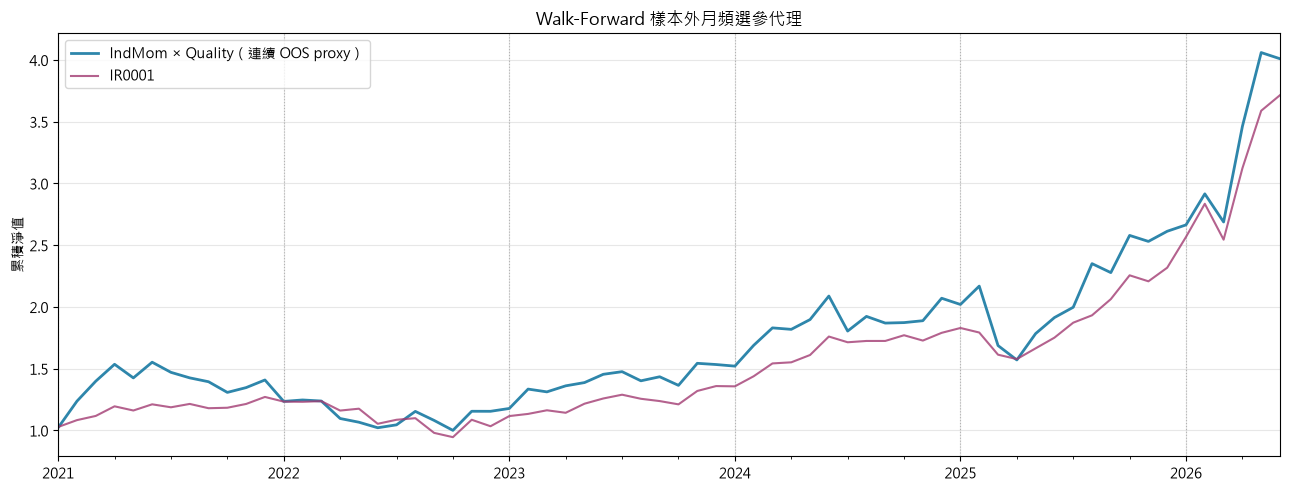

In [42]:
# ── 7-C  一次連續計算所有 Walk-Forward OOS 月頻代理 ───────────
stitched_oos, stitched_diag = simple_backtest(
    walkforward_picks, roi_lookup, price_monthly, return_diagnostics=True
)
expected_oos_months = pd.date_range(START_DATE, END_DATE, freq='ME')
if not stitched_oos.index.equals(expected_oos_months):
    raise RuntimeError(
        '連續 OOS 月份不完整：'
        f'expected={len(expected_oos_months)}, actual={len(stitched_oos)}'
    )

stitched_bm = bm_series.reindex(stitched_oos.index)
if stitched_bm.isna().any():
    missing = stitched_bm.index[stitched_bm.isna()].strftime('%Y-%m').tolist()
    raise RuntimeError(f'基準對齊後仍缺值：{missing}')

strategy_metrics = calc_metrics(stitched_oos)
benchmark_metrics = calc_metrics(stitched_bm)
print('=== 連續 Walk-Forward 月頻選參代理（含近似交易成本、不含停損）===')
print(f"期間：{stitched_oos.index.min().date()} ~ {stitched_oos.index.max().date()} "
      f"({len(stitched_oos)} 個月)")
print(f"策略總報酬：{strategy_metrics['總報酬%']:.2f}%")
print(f"基準總報酬：{benchmark_metrics['總報酬%']:.2f}%")
print(f"策略 Sharpe：{strategy_metrics['Sharpe']:.3f}")
print(f"策略最大回撤：{strategy_metrics['最大回撤%']:.2f}%")
print(f"缺少精確次月報酬的持股筆數：{int(stitched_diag['missing_forward_returns'].sum())}")
print(f"缺少精確次月報酬的累計權重：{stitched_diag['missing_forward_weight'].sum():.2%}")
print(f"代理交易成本合計：{stitched_diag['proxy_cost'].sum():.2%}")
print(f"代理融資成本合計：{stitched_diag['financing_cost'].sum():.2%}")

fig, ax = plt.subplots(figsize=(13, 5))
(1.0 + stitched_oos).cumprod().plot(
    ax=ax, label='IndMom × Quality（連續 OOS proxy）', color='#2E86AB', linewidth=2
)
(1.0 + stitched_bm).cumprod().plot(
    ax=ax, label='IR0001', color='#A23B72', linewidth=1.5, alpha=0.8
)
for _, _, oos_start, _ in fold_bounds:
    ax.axvline(oos_start, color='gray', lw=0.8, ls=':', alpha=0.5)
ax.set_title('Walk-Forward 樣本外月頻選參代理')
ax.set_ylabel('累積淨值')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [43]:
# ── 7-D  直接執行 ingest，鎖定本次 snapshot 並驗證股票與日期 ──
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

# 本機 zipline-tej 的 bundle_timestamp 篩選有缺陷；每次執行使用只有一個
# snapshot 的獨立 ZIPLINE_ROOT，才能真正鎖定本次 ingest。
BUNDLE_ROOT = Path(tempfile.mkdtemp(prefix='indmom_zipline_')).resolve()
os.environ['ZIPLINE_ROOT'] = str(BUNDLE_ROOT)

from zipline.data import bundles
from zipline.data.bundles.core import ingestions_for_bundle, to_bundle_ingest_dirname

all_selected = sorted({
    ticker for picks in walkforward_picks.values() for ticker in picks
})
ingest_pool = sorted(set(all_selected) | {'IR0001'})
if len(ingest_pool) <= 1:
    raise RuntimeError('沒有可供 Zipline ingest 的入選股票。')

ingest_env = os.environ.copy()
ingest_env['mdate'] = f"{START_DATE.replace('-', '')} {END_DATE.replace('-', '')}"
ingest_env['ticker'] = ' '.join(ingest_pool)

bundled_cli = Path(sys.executable).with_name('zipline.exe')
zipline_cli = str(bundled_cli) if bundled_cli.exists() else shutil.which('zipline')
if not zipline_cli:
    raise FileNotFoundError('找不到目前 Python 環境的 zipline CLI。')

try:
    ingests_before = set(ingestions_for_bundle('tquant'))
except (FileNotFoundError, ValueError):
    ingests_before = set()

print(f'開始 ingest：{len(ingest_pool):,} 檔，{START_DATE} ~ {END_DATE}')
subprocess.run(
    [zipline_cli, 'ingest', '-b', 'tquant'],
    env=ingest_env,
    check=True,
)

ingests_after = set(ingestions_for_bundle('tquant'))
new_ingests = sorted(ingests_after - ingests_before, reverse=True)
if len(new_ingests) != 1:
    raise RuntimeError(
        f'預期建立 1 個新 tquant snapshot，實際為 {len(new_ingests)}：{new_ingests}'
    )
INGEST_TIMESTAMP = new_ingests[0]
INGEST_RUN_ID = to_bundle_ingest_dirname(INGEST_TIMESTAMP)

bundle_data = bundles.load('tquant')
finder = bundle_data.asset_finder
loaded_run_id = Path(finder.engine.url.database).parent.name
if loaded_run_id != INGEST_RUN_ID:
    raise RuntimeError(
        f'實際載入 snapshot {loaded_run_id}，不是本次 ingest {INGEST_RUN_ID}。'
    )
bundle_assets = finder.retrieve_all(finder.equities_sids)
assets_by_symbol = {str(asset.symbol): asset for asset in bundle_assets}
missing_symbols = sorted(set(ingest_pool) - set(assets_by_symbol))
if missing_symbols:
    raise RuntimeError(
        f'ingest 完成但 bundle 缺少 {len(missing_symbols)} 檔：{missing_symbols[:20]}'
    )

# 直接讀 daily bars；只看 asset metadata 會放過被 reindex 成 0 的缺資料日。
daily_reader = bundle_data.equity_daily_bar_reader
all_sessions = daily_reader.sessions
oos_sessions = all_sessions[
    (all_sessions >= pd.Timestamp(START_DATE, tz='UTC'))
    & (all_sessions <= pd.Timestamp(END_DATE, tz='UTC'))
]
if oos_sessions.empty:
    raise RuntimeError('bundle 在 OOS 期間沒有任何交易日。')

ordered_symbols = sorted(ingest_pool)
ordered_assets = [assets_by_symbol[ticker] for ticker in ordered_symbols]
close_array, volume_array = daily_reader.load_raw_arrays(
    ['close', 'volume'],
    oos_sessions[0],
    oos_sessions[-1],
    [asset.sid for asset in ordered_assets],
)
valid_close = np.isfinite(close_array) & (close_array > 0)
valid_trade_bar = valid_close & np.isfinite(volume_array) & (volume_array > 0)
symbol_col = {ticker: i for i, ticker in enumerate(ordered_symbols)}
session_periods = oos_sessions.tz_localize(None).to_period('M')

coverage_failures = []
for signal_date, picks in walkforward_picks.items():
    hold_period = (signal_date + pd.offsets.MonthEnd(1)).to_period('M')
    month_rows = session_periods == hold_period
    for ticker in picks:
        if not valid_trade_bar[month_rows, symbol_col[ticker]].any():
            coverage_failures.append((ticker, str(hold_period), 'no positive close/volume bar'))

benchmark_asset = assets_by_symbol['IR0001']
benchmark_col = symbol_col['IR0001']
if (
    benchmark_asset.start_date > oos_sessions[0]
    or benchmark_asset.end_date < oos_sessions[-1]
    or not valid_close[:, benchmark_col].all()
):
    coverage_failures.append(
        ('IR0001', 'full OOS', benchmark_asset.start_date, benchmark_asset.end_date,
         int((~valid_close[:, benchmark_col]).sum()))
    )
if coverage_failures:
    raise RuntimeError(f'bundle 日期覆蓋不足（前 20 筆）：{coverage_failures[:20]}')

print(
    f'tquant bundle 驗證完成：snapshot={INGEST_RUN_ID}，'
    f'{len(bundle_assets):,} 檔，所有需求股票與月份皆存在。\n'
    f'隔離 bundle root：{BUNDLE_ROOT}'
)


開始 ingest：317 檔，2021-01-01 ~ 2026-06-30
tquant bundle 驗證完成：snapshot=2026-07-15T06;00;57.729091，317 檔，所有需求股票與月份皆存在。
隔離 bundle root：C:\Users\2026061502\AppData\Local\Temp\tmpoyih3uim\indmom_zipline_ifv8z5ez


In [44]:
# ── 7-E  連續 Zipline 狀態機：先賣後買 + 停損冷卻 ───────────
from zipline.api import (
    cancel_order, date_rules, get_open_orders, order_target_percent,
    record, schedule_function, set_benchmark, set_commission,
    set_execution_price_type, set_max_leverage, set_slippage, symbol,
    time_rules,
)
from zipline.finance import slippage
from zipline.finance.commission import Custom_TW_Commission


def build_continuous_strategy(target_schedule):
    """target_schedule: {'YYYY-MM': {ticker: target_weight}}。"""
    weight_tolerance = 0.0025

    def month_key(dt):
        timestamp = pd.Timestamp(dt)
        if timestamp.tz is None:
            timestamp = timestamp.tz_localize('UTC')
        return timestamp.tz_convert('Asia/Taipei').strftime('%Y-%m')

    def cancel_all_open_orders():
        for orders in get_open_orders().values():
            for order in orders:
                cancel_order(order)

    def open_order_count():
        return sum(len(orders) for orders in get_open_orders().values())

    def resolve_month_target(ticker_weights):
        resolved = {}
        for ticker, weight in ticker_weights.items():
            try:
                resolved[symbol(ticker)] = float(weight)
            except Exception as exc:
                raise RuntimeError(f'無法在當期解析 bundle 股票 {ticker}') from exc
        return resolved

    def current_weight(context, data, asset):
        position = context.portfolio.positions.get(asset)
        amount = 0.0 if position is None else float(position.amount)
        price = data.current(asset, 'price')
        if not np.isfinite(price) or context.portfolio.portfolio_value <= 0:
            return 0.0
        return amount * float(price) / float(context.portfolio.portfolio_value)

    def submit_target(context, data, asset, target_weight):
        if get_open_orders(asset):
            return True
        position = context.portfolio.positions.get(asset)
        if target_weight == 0.0 and (position is None or position.amount == 0):
            return True
        if not data.can_trade(asset):
            context.untradable_retries += 1
            return False
        order_id = order_target_percent(asset, target_weight)
        if order_id is not None:
            return True
        if target_weight == 0.0:
            # 清倉不能用權重容忍值放過非零殘股，否則狀態機可能永久卡在 EXITING。
            position = context.portfolio.positions.get(asset)
            if position is None or position.amount == 0:
                return True
            context.rejected_order_retries += 1
            return False
        if abs(current_weight(context, data, asset) - target_weight) <= weight_tolerance:
            return True
        context.rejected_order_retries += 1
        return False

    def submit_batch(context, data, target_weights):
        context.retry_targets = {}
        for asset in sorted(target_weights, key=lambda a: str(a.symbol)):
            target_weight = target_weights[asset]
            if not submit_target(context, data, asset, target_weight):
                context.retry_targets[asset] = target_weight

    def retry_untradable(context, data):
        for asset, target_weight in list(context.retry_targets.items()):
            if submit_target(context, data, asset, target_weight):
                context.retry_targets.pop(asset, None)

    def orders_finished(context):
        return not context.retry_targets and open_order_count() == 0

    def start_buy_phase(context, data):
        buy_targets = {}
        for asset, target_weight in context.active_targets.items():
            if target_weight > current_weight(context, data, asset) + weight_tolerance:
                buy_targets[asset] = target_weight
        submit_batch(context, data, buy_targets)
        context.rebalance_stage = 'BUYING' if (buy_targets or not orders_finished(context)) else 'IDLE'

    def start_rebalance(context, data):
        """先完成退出與減碼，下一交易日才允許加碼，避免 partial fills 造成槓桿暴衝。"""
        cancel_all_open_orders()
        sell_targets = {}
        assets = set(context.portfolio.positions.keys()) | set(context.active_targets)
        for asset in assets:
            target_weight = context.active_targets.get(asset, 0.0)
            if target_weight < current_weight(context, data, asset) - weight_tolerance:
                sell_targets[asset] = target_weight
        submit_batch(context, data, sell_targets)
        if sell_targets or not orders_finished(context):
            context.rebalance_stage = 'SELLING'
        else:
            start_buy_phase(context, data)

    def advance_rebalance(context, data):
        if context.rebalance_stage == 'SELLING':
            retry_untradable(context, data)
            if orders_finished(context):
                start_buy_phase(context, data)
        elif context.rebalance_stage == 'BUYING':
            retry_untradable(context, data)
            if orders_finished(context):
                context.rebalance_stage = 'IDLE'

    def start_liquidation(context, data):
        cancel_all_open_orders()
        liquidation_targets = {
            asset: 0.0
            for asset, position in context.portfolio.positions.items()
            if position.amount != 0
        }
        submit_batch(context, data, liquidation_targets)

    def portfolio_is_flat(context):
        has_position = any(
            position.amount != 0 for position in context.portfolio.positions.values()
        )
        return not has_position and orders_finished(context)

    def before_trading_start(context, data):
        current_month = month_key(data.current_dt)
        if current_month != context.current_month:
            if current_month not in context.target_schedule:
                raise RuntimeError(f'目標排程缺少月份 {current_month}')
            context.current_month = current_month
            context.resume_targets = resolve_month_target(context.target_schedule[current_month])
            if context.state == 'RUNNING':
                context.month_changed = True
        # 日頻模式在 BTS 送單，於本交易日收盤成交。
        drive_orders(context, data)

    def drive_orders(context, data):
        if context.state == 'EXITING':
            if not context.exit_started:
                start_liquidation(context, data)
                context.exit_started = True
            else:
                retry_untradable(context, data)
            if portfolio_is_flat(context):
                context.state = 'COOLDOWN'
                context.cooldown_left = STOP_LOSS_COOLDOWN
            return

        if context.state == 'COOLDOWN':
            context.cooldown_left -= 1
            if context.cooldown_left <= 0:
                context.state = 'RUNNING'
                context.portfolio_peak = float(context.portfolio.portfolio_value)
                context.active_targets = dict(context.resume_targets)
                start_rebalance(context, data)
                context.month_changed = False
            return

        if context.month_changed:
            context.active_targets = dict(context.resume_targets)
            start_rebalance(context, data)
            context.month_changed = False
        else:
            advance_rebalance(context, data)

    def risk_check(context, data):
        value = float(context.portfolio.portfolio_value)
        if context.state == 'RUNNING':
            context.portfolio_peak = max(context.portfolio_peak, value)
            drawdown = value / context.portfolio_peak - 1.0
            if ENABLE_STOP_LOSS and drawdown <= STOP_LOSS_PCT:
                cancel_all_open_orders()
                context.state = 'EXITING'
                context.exit_started = False
                context.retry_targets = {}
                context.rebalance_stage = 'IDLE'
        else:
            drawdown = value / context.portfolio_peak - 1.0 if context.portfolio_peak else 0.0

        # 最終交易日先讓當日成交完成，再取消無法於研究期內繼續成交的餘單。
        current_date = pd.Timestamp(data.current_dt)
        if current_date.tz is not None:
            current_date = current_date.tz_convert('Asia/Taipei').tz_localize(None)
        if current_date.normalize() >= pd.Timestamp(END_DATE):
            remaining_orders = open_order_count()
            remaining_retries = len(context.retry_targets)
            if remaining_orders:
                context.terminal_cancelled_orders += remaining_orders
                cancel_all_open_orders()
            if remaining_retries:
                context.terminal_abandoned_retries += remaining_retries
                context.retry_targets = {}
            context.rebalance_stage = 'IDLE'

        record(
            strategy_state={'RUNNING': 0, 'EXITING': 1, 'COOLDOWN': 2}[context.state],
            rebalance_stage={'IDLE': 0, 'SELLING': 1, 'BUYING': 2}[context.rebalance_stage],
            portfolio_drawdown=drawdown,
            num_positions=len(context.portfolio.positions),
            leverage=context.account.leverage,
            borrowed_exposure=max(float(context.account.leverage) - 1.0, 0.0),
            retry_count=len(context.retry_targets),
            open_order_count=open_order_count(),
            untradable_retries=context.untradable_retries,
            rejected_order_retries=context.rejected_order_retries,
            terminal_cancelled_orders=context.terminal_cancelled_orders,
            terminal_abandoned_retries=context.terminal_abandoned_retries,
        )

    def initialize(context):
        set_commission(
            Custom_TW_Commission(tax=0.003, discount=0.6, min_trade_cost=20.0)
        )
        set_slippage(
            equities=slippage.VolumeShareSlippage(
                volume_limit=VOLUME_LIMIT,
                price_impact=PRICE_IMPACT,
            )
        )
        set_execution_price_type('close')
        set_max_leverage(MAX_GROSS_LEVERAGE)
        set_benchmark(symbol('IR0001'))

        context.target_schedule = target_schedule
        context.current_month = None
        context.resume_targets = {}
        context.active_targets = {}
        context.retry_targets = {}
        context.month_changed = False
        context.rebalance_stage = 'IDLE'
        context.state = 'RUNNING'
        context.exit_started = False
        context.cooldown_left = 0
        context.portfolio_peak = float(context.portfolio.portfolio_value)
        context.untradable_retries = 0
        context.rejected_order_retries = 0
        context.terminal_cancelled_orders = 0
        context.terminal_abandoned_retries = 0

        schedule_function(
            risk_check, date_rules.every_day(), time_rules.market_close()
        )

    return initialize, before_trading_start


print('1.5x 連續 Zipline 狀態機建立完成（先賣後買、含槓桿上限）。')


1.5x 連續 Zipline 狀態機建立完成（先賣後買、含槓桿上限）。


In [45]:
# ── 7-F  run_algorithm：合併全部 fold，只執行一次連續 Zipline 回測 ──
from zipline import run_algorithm

target_weight_schedule = {}
for signal_date, picks in sorted(walkforward_picks.items()):
    realized_month = signal_date + pd.offsets.MonthEnd(1)
    key = realized_month.strftime('%Y-%m')
    if key in target_weight_schedule:
        raise RuntimeError(f'重複的 Zipline 目標月份：{key}')
    base_weights = compute_vol_weights(picks, signal_date, price_monthly) if picks else {}
    target_weight_schedule[key] = {
        ticker: weight * LEVERAGE for ticker, weight in base_weights.items()
    }

expected_keys = {
    d.strftime('%Y-%m') for d in pd.date_range(START_DATE, END_DATE, freq='ME')
}
if set(target_weight_schedule) != expected_keys:
    raise RuntimeError('Zipline 目標月份與完整 OOS 月份不一致。')
for month, weights in target_weight_schedule.items():
    gross_target = sum(abs(weight) for weight in weights.values())
    if weights and not np.isclose(gross_target, LEVERAGE, atol=1e-10):
        raise RuntimeError(
            f'{month} 目標 gross leverage={gross_target:.6f}，不是 {LEVERAGE:.2f}。'
        )
latest_ingest = ingestions_for_bundle('tquant')[0]
if latest_ingest != INGEST_TIMESTAMP:
    raise RuntimeError(
        f'執行前最新 snapshot 已變成 {latest_ingest}，預期為 {INGEST_TIMESTAMP}。'
    )

initialize_fn, before_trading_start_fn = build_continuous_strategy(target_weight_schedule)
print(f'執行單一路徑 Zipline：{START_DATE} ~ {END_DATE}，'
      f'{len(target_weight_schedule)} 次月度目標。')
zipline_results = run_algorithm(
    start=pd.Timestamp(START_DATE, tz='UTC'),
    end=pd.Timestamp(END_DATE, tz='UTC'),
    initialize=initialize_fn,
    before_trading_start=before_trading_start_fn,
    bundle='tquant',
    bundle_timestamp=INGEST_TIMESTAMP,
    data_frequency='daily',
    capital_base=CAPITAL_BASE,
)
if zipline_results.empty:
    raise RuntimeError('Zipline 未產生任何績效資料。')
print(f'Zipline 完成：{len(zipline_results):,} 個交易日。')
zipline_results.tail(3)


執行單一路徑 Zipline：2021-01-01 ~ 2026-06-30，66 次月度目標。
Zipline 完成：1,330 個交易日。


,period_open,period_close,longs_count,shorts_count,starting_value,ending_exposure,orders,portfolio_value,transactions,ending_cash,...,max_leverage,max_drawdown,sharpe,alpha,beta,benchmark_period_return,excess_return,benchmark_volatility,algorithm_period_return,treasury_period_return
2026-06-26 13:30:00+08:00,2026-06-26 09:01:00+08:00,2026-06-26 13:30:00+08:00,40,1,72888432.1,69672732.20,"[{'id': '1d49fa6d439f481ba8cfd7ef4d6f7a81', 'd...",4.670221e+07,"[{'amount': 4550, 'dt': 2026-06-26 13:30:00+08...",-2.297053e+07,...,1.609567,-0.307553,1.417312,0.121688,0.777829,2.546345,1.123876,0.204809,3.670221,0.0
2026-06-29 13:30:00+08:00,2026-06-29 09:01:00+08:00,2026-06-29 13:30:00+08:00,40,1,69672732.2,69960753.90,"[{'id': '1d49fa6d439f481ba8cfd7ef4d6f7a81', 'd...",4.689349e+07,"[{'amount': 3350, 'dt': 2026-06-29 13:30:00+08...",-2.306726e+07,...,1.609567,-0.307553,1.420222,0.120906,0.777677,2.580648,1.108701,0.204767,3.689349,0.0
2026-06-30 13:30:00+08:00,2026-06-30 09:01:00+08:00,2026-06-30 13:30:00+08:00,40,1,69960753.9,71376600.05,"[{'id': '1d49fa6d439f481ba8cfd7ef4d6f7a81', 'd...",4.823931e+07,"[{'amount': 2425, 'dt': 2026-06-30 13:30:00+08...",-2.313729e+07,...,1.609567,-0.307553,1.441909,0.122406,0.778603,2.672207,1.151724,0.204968,3.823931,0.0


首個交易日無前一日基準價：benchmark_return 設為 0%，未刪除該交易日。
=== 正式連續 Zipline Walk-Forward（1.5x、含成本、融資與停損）===
期間：2021-01-04 ~ 2026-06-30 (1330 個交易日)
策略總報酬（融資後）：363.22%
策略總報酬（融資前）：382.39%
基準總報酬：267.22%
融資成本假設：年率 6.00%
累計融資拖累（單期成本加總）：4.06%
實際最大 gross leverage：1.610x
策略年化報酬：32.25%
策略年化波動：22.44%
策略 Sharpe：1.408
策略最大回撤：-30.81%
累計不可交易重試次數： 0
累計拒單重試次數： 0
期末取消未成交餘單： 1
期末放棄不可交易重試： 0


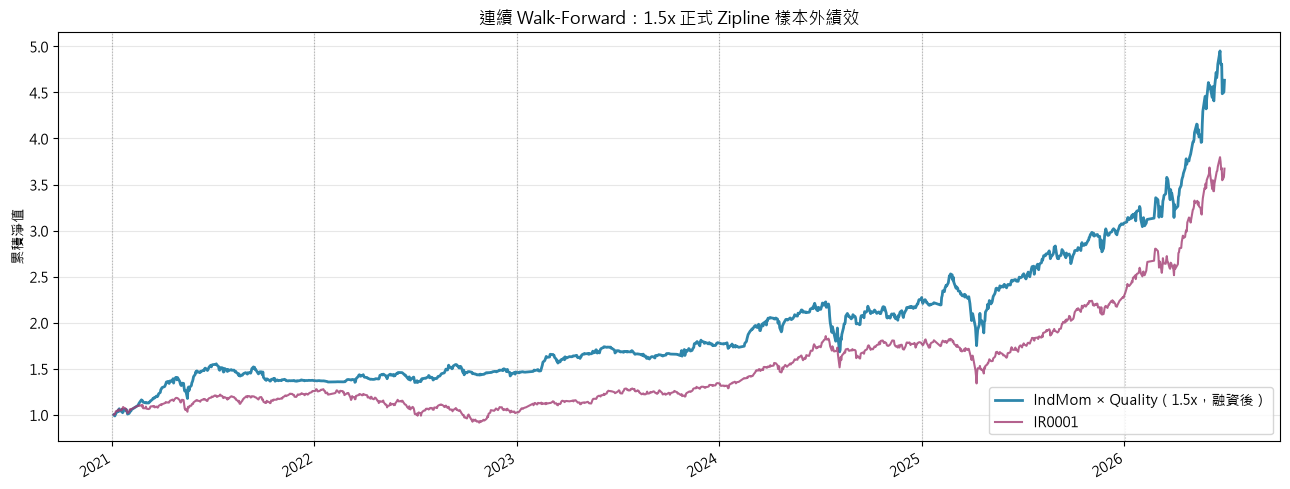

In [46]:
# ── 7-G  正式、連續且含交易成本的 Zipline 績效 ──────────────
def calc_daily_metrics(daily_returns):
    returns = pd.Series(daily_returns, dtype=float).dropna().sort_index()
    if returns.empty:
        raise ValueError('日報酬為空。')
    gross_wealth = float((1.0 + returns).prod())
    total_return = gross_wealth - 1.0
    elapsed_years = max(
        (returns.index[-1] - returns.index[0]).total_seconds()
        / (365.2425 * 24 * 60 * 60),
        1.0 / 365.2425,
    )
    annual_return = gross_wealth ** (1.0 / elapsed_years) - 1.0 if gross_wealth > 0 else -1.0
    annual_vol = returns.std(ddof=1) * np.sqrt(252.0)
    sharpe = (returns.mean() * 252.0) / annual_vol if annual_vol > 0 else np.nan
    wealth = pd.concat([
        pd.Series([1.0], index=[returns.index.min() - pd.Timedelta(days=1)]),
        (1.0 + returns).cumprod(),
    ])
    max_drawdown = float((wealth / wealth.cummax() - 1.0).min())
    return {
        '總報酬%': total_return * 100.0,
        '年化報酬%': annual_return * 100.0,
        '年化波動%': annual_vol * 100.0,
        'Sharpe': sharpe,
        '最大回撤%': max_drawdown * 100.0,
    }

required_perf = {'returns', 'benchmark_return', 'leverage'}
missing = required_perf.difference(zipline_results.columns)
if missing:
    raise KeyError(f'Zipline 績效缺少欄位：{sorted(missing)}')

observed_max_leverage = float(zipline_results['leverage'].dropna().max())
if observed_max_leverage > MAX_GROSS_LEVERAGE + 1e-6:
    raise RuntimeError(
        f'實際 gross leverage {observed_max_leverage:.3f} 超過硬上限 {MAX_GROSS_LEVERAGE:.2f}。'
    )

perf = zipline_results[['returns', 'benchmark_return']].copy()
perf['returns_before_financing'] = perf['returns']
daily_financing_rate = (1.0 + ANNUAL_FINANCING_RATE) ** (1.0 / 252.0) - 1.0
borrowed_exposure = zipline_results['leverage'].shift(1).fillna(0.0).sub(1.0).clip(lower=0.0)
perf['financing_cost'] = borrowed_exposure * daily_financing_rate
perf['returns'] = perf['returns_before_financing'] - perf['financing_cost']
strategy_missing = perf['returns'].isna()
if strategy_missing.any():
    bad_dates = perf.index[strategy_missing].strftime('%Y-%m-%d').tolist()
    raise RuntimeError(f'策略日報酬含缺值，禁止繼續：{bad_dates[:20]}')

benchmark_missing = perf['benchmark_return'].isna()
unexpected_benchmark_missing = benchmark_missing.copy()
if len(unexpected_benchmark_missing):
    unexpected_benchmark_missing.iloc[0] = False
if unexpected_benchmark_missing.any():
    bad_dates = perf.index[unexpected_benchmark_missing].strftime('%Y-%m-%d').tolist()
    raise RuntimeError(f'基準日報酬在回測中途缺值，禁止繼續：{bad_dates[:20]}')
if benchmark_missing.iloc[0]:
    perf.iloc[0, perf.columns.get_loc('benchmark_return')] = 0.0
    print('首個交易日無前一日基準價：benchmark_return 設為 0%，未刪除該交易日。')

required_state_columns = {'strategy_state', 'retry_count', 'open_order_count'}
missing_state = required_state_columns.difference(zipline_results.columns)
if missing_state:
    raise KeyError(f'Zipline 終態檢查缺少欄位：{sorted(missing_state)}')
final_row = zipline_results.iloc[-1]
if (
    int(final_row['strategy_state']) == 1
    or int(final_row['retry_count']) > 0
    or int(final_row['open_order_count']) > 0
):
    raise RuntimeError(
        '回測結束時仍有未完成退出／重試／掛單：'
        f"state={final_row['strategy_state']}, retry={final_row['retry_count']}, "
        f"open={final_row['open_order_count']}"
    )

formal_strategy = calc_daily_metrics(perf['returns'])
formal_strategy_before_financing = calc_daily_metrics(perf['returns_before_financing'])
formal_benchmark = calc_daily_metrics(perf['benchmark_return'])
print('=== 正式連續 Zipline Walk-Forward（1.5x、含成本、融資與停損）===')
print(f"期間：{perf.index.min().date()} ~ {perf.index.max().date()} "
      f"({len(perf)} 個交易日)")
print(f"策略總報酬（融資後）：{formal_strategy['總報酬%']:.2f}%")
print(f"策略總報酬（融資前）：{formal_strategy_before_financing['總報酬%']:.2f}%")
print(f"基準總報酬：{formal_benchmark['總報酬%']:.2f}%")
print(f"融資成本假設：年率 {ANNUAL_FINANCING_RATE:.2%}")
print(f"累計融資拖累（單期成本加總）：{perf['financing_cost'].sum():.2%}")
print(f"實際最大 gross leverage：{observed_max_leverage:.3f}x")
print(f"策略年化報酬：{formal_strategy['年化報酬%']:.2f}%")
print(f"策略年化波動：{formal_strategy['年化波動%']:.2f}%")
print(f"策略 Sharpe：{formal_strategy['Sharpe']:.3f}")
print(f"策略最大回撤：{formal_strategy['最大回撤%']:.2f}%")
if 'untradable_retries' in zipline_results:
    print('累計不可交易重試次數：', int(zipline_results['untradable_retries'].dropna().max()))
if 'rejected_order_retries' in zipline_results:
    print('累計拒單重試次數：', int(zipline_results['rejected_order_retries'].dropna().max()))
if 'terminal_cancelled_orders' in zipline_results:
    print('期末取消未成交餘單：', int(zipline_results['terminal_cancelled_orders'].dropna().iloc[-1]))
if 'terminal_abandoned_retries' in zipline_results:
    print('期末放棄不可交易重試：', int(zipline_results['terminal_abandoned_retries'].dropna().iloc[-1]))

cumulative_strategy = (1.0 + perf['returns']).cumprod()
cumulative_benchmark = (1.0 + perf['benchmark_return']).cumprod()
fig, ax = plt.subplots(figsize=(13, 5))
cumulative_strategy.plot(
    ax=ax, label='IndMom × Quality（1.5x，融資後）', color='#2E86AB', linewidth=2
)
cumulative_benchmark.plot(
    ax=ax, label='IR0001', color='#A23B72', linewidth=1.5, alpha=0.8
)
for _, _, oos_start, _ in fold_bounds:
    ax.axvline(pd.Timestamp(oos_start, tz='UTC'), color='gray', lw=0.8, ls=':', alpha=0.5)
ax.set_title('連續 Walk-Forward：1.5x 正式 Zipline 樣本外績效')
ax.set_ylabel('累積淨值')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 8｜Pyfolio 完整績效分析

以下直接承接 `run_algorithm` 回傳的 `zipline_results`。持倉與成交明細由
`pyfolio.utils.extract_rets_pos_txn_from_zipline` 擷取；報酬則採用前節已扣除融資成本的正式日報酬，
並將 IR0001 傳入 `benchmark_rets`，產生完整 tear sheet。

In [49]:
# ── 8-A  將 run_algorithm 結果安全轉為 Pyfolio 格式 ─────────
import pyfolio as pf
from collections import OrderedDict

required_pyfolio_columns = {
    'returns', 'positions', 'transactions', 'ending_cash'
}
missing_pyfolio_columns = required_pyfolio_columns.difference(
    zipline_results.columns
)
if missing_pyfolio_columns:
    raise KeyError(
        f'Pyfolio 擷取缺少欄位：{sorted(missing_pyfolio_columns)}'
    )

# TEJ 版 extractor 會原地正規化輸入 index；必須傳 copy，不能改動正式結果。
pyfolio_source = zipline_results.copy()
(
    pf_returns_before_financing,
    pf_positions,
    pf_transactions,
) = pf.utils.extract_rets_pos_txn_from_zipline(pyfolio_source)

if len(pf_returns_before_financing) != len(perf):
    raise RuntimeError(
        'Pyfolio 報酬長度與正式績效不一致：'
        f'{len(pf_returns_before_financing)} != {len(perf)}'
    )
if not np.allclose(
    pf_returns_before_financing.to_numpy(dtype=float),
    perf['returns_before_financing'].to_numpy(dtype=float),
    rtol=1e-10,
    atol=1e-12,
    equal_nan=False,
):
    raise RuntimeError('Pyfolio 擷取的 Zipline 原始報酬與正式績效順序不一致。')

# extractor 產生的 UTC 00:00 index 是 Pyfolio 的標準日期索引；
# 僅以融資後正式報酬覆蓋數值，避免 tear sheet 誤用融資前績效。
pf_returns = pf_returns_before_financing.astype(float).copy()
pf_returns.iloc[:] = perf['returns'].to_numpy(dtype=float)
pf_returns.name = 'IndMom_Quality_1.5x_net_financing'
pf_benchmark_returns = pd.Series(
    perf['benchmark_return'].to_numpy(dtype=float),
    index=pf_returns.index,
    name='IR0001',
)
pf_transactions = pf_transactions.sort_index()

if pf_returns.isna().any() or pf_benchmark_returns.isna().any():
    raise RuntimeError('Pyfolio 策略或基準報酬含缺值。')
if not pf_returns.index.is_unique:
    raise RuntimeError('Pyfolio 報酬索引含重複交易日。')
if not pf_positions.index.equals(pf_returns.index):
    def _normalized_dates(idx):
        idx = pd.DatetimeIndex(idx)
        if idx.tz is not None:
            idx = idx.tz_convert('UTC').tz_localize(None)
        return idx.normalize()

    positions_dates = _normalized_dates(pf_positions.index)
    returns_dates = _normalized_dates(pf_returns.index)
    missing_in_positions = returns_dates.difference(positions_dates)
    missing_in_returns = positions_dates.difference(returns_dates)

    if len(missing_in_returns) > 0 or not positions_dates.is_unique:
        raise RuntimeError(
            'Pyfolio 持倉日期與報酬日期不一致（非全現金缺漏可解釋）：'
            f'positions 多出或重複的日期共 {len(missing_in_returns)} 筆，'
            f'例如 {missing_in_returns[:5].tolist()}；'
            f'positions 缺少的日期共 {len(missing_in_positions)} 筆，'
            f'例如 {missing_in_positions[:5].tolist()}'
        )

    # positions 缺漏的日期通常是全現金（尚未建倉、換股空窗期、出清後等）造成
    # extractor 沒有為該日寫入 positions 列；用當日 ending_cash 補一列全現金部位。
    zipline_dates = _normalized_dates(zipline_results.index)
    cash_lookup = pd.Series(
        zipline_results['ending_cash'].to_numpy(dtype=float), index=zipline_dates,
    )
    cash_only = pd.DataFrame(0.0, index=missing_in_positions, columns=pf_positions.columns)
    if 'cash' in cash_only.columns:
        cash_only['cash'] = cash_lookup.reindex(missing_in_positions).to_numpy()
        if cash_only['cash'].isna().any():
            raise RuntimeError('Pyfolio 全現金補值時，ending_cash 對應不到缺漏日期。')

    # 先統一成 tz-naive 正規化日期再合併，避免 tz-aware/tz-naive 混雜導致 sort_index 出錯
    pf_positions = pf_positions.set_axis(positions_dates, axis=0)
    pf_positions = pd.concat([pf_positions, cash_only]).sort_index()
    pf_positions.index = pf_returns.index
    print(
        f'Pyfolio 持倉已自動補上 {len(missing_in_positions)} 天全現金部位'
        '（無任何股票曝險）。'
    )
if pf_transactions.empty:
    raise RuntimeError('Pyfolio 成交明細為空。')
if not {'amount', 'price', 'symbol'}.issubset(pf_transactions.columns):
    raise KeyError('Pyfolio 成交明細缺少 amount、price 或 symbol 欄位。')

pyfolio_total_return = float((1.0 + pf_returns).prod() - 1.0)
if not np.isclose(
    pyfolio_total_return,
    formal_strategy['總報酬%'] / 100.0,
    rtol=1e-10,
    atol=1e-12,
):
    raise RuntimeError('Pyfolio 累積報酬與正式融資後績效不一致。')

position_count = sum(column != 'cash' for column in pf_positions.columns)
print(
    f'Pyfolio 輸入完成：{len(pf_returns):,} 日、'
    f'{position_count} 個持倉欄位、{len(pf_transactions):,} 筆成交。'
)
print(f'Pyfolio 融資後累積報酬核對：{pyfolio_total_return:.2%}')
print('報酬採融資後口徑；持倉、曝險與成交採 Zipline 實際執行結果。')


Pyfolio 持倉已自動補上 1 天全現金部位（無任何股票曝險）。
Pyfolio 輸入完成：1,330 日、300 個持倉欄位、5,243 筆成交。
Pyfolio 融資後累積報酬核對：363.22%
報酬採融資後口徑；持倉、曝險與成交採 Zipline 實際執行結果。


策略,IndMom × Quality
回測引擎,zipline.run_algorithm
目標 Gross Leverage,1.50x
實際最高 Gross Leverage,1.610x
融資利率假設,6.00%
Start date,2021-01-04
End date,2026-06-30
Total months,63
,Backtest
Annual return,33.706%
Cumulative returns,363.221%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,30.81,2025-02-21,2025-04-09,2025-07-03,90
1,24.38,2024-07-11,2024-08-05,2024-12-26,114
2,16.34,2021-04-26,2021-05-17,2021-05-28,24
3,13.06,2021-07-08,2022-07-06,2023-02-17,395
4,12.18,2026-03-18,2026-03-31,2026-04-16,20


c:\Users\2026061502\Desktop\TQuant Lab 教學\.venv\Lib\site-packages\seaborn\matrix.py:243: PendingDeprecationWarning: The set_bad function will be deprecated in a future version. Use cmap.with_extremes(bad=...) or Colormap(bad=...) instead.
  self.cmap.set_bad(bad)
c:\Users\2026061502\Desktop\TQuant Lab 教學\.venv\Lib\site-packages\pyfolio\plotting.py:1616: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])
c:\Users\2026061502\Desktop\TQuant Lab 教學\.venv\Lib\site-packages\pyfolio\tears.py:1113: UserWarning: Passed returns do not overlap with anyinteresting times.
  warnings.warn(


Top 10 long positions of all time,max
sid,
1707,31.73%
3705,28.25%
2548,27.67%
2450,23.06%
6754,22.25%
1537,22.15%
1808,21.07%
3030,20.76%
1227,19.91%


Top 10 short positions of all time,max
sid,
6796,-0.21%
6776,-0.02%


Top 10 positions of all time,max
sid,
1707,31.73%
3705,28.25%
2548,27.67%
2450,23.06%
6754,22.25%
1537,22.15%
1808,21.07%
3030,20.76%
1227,19.91%


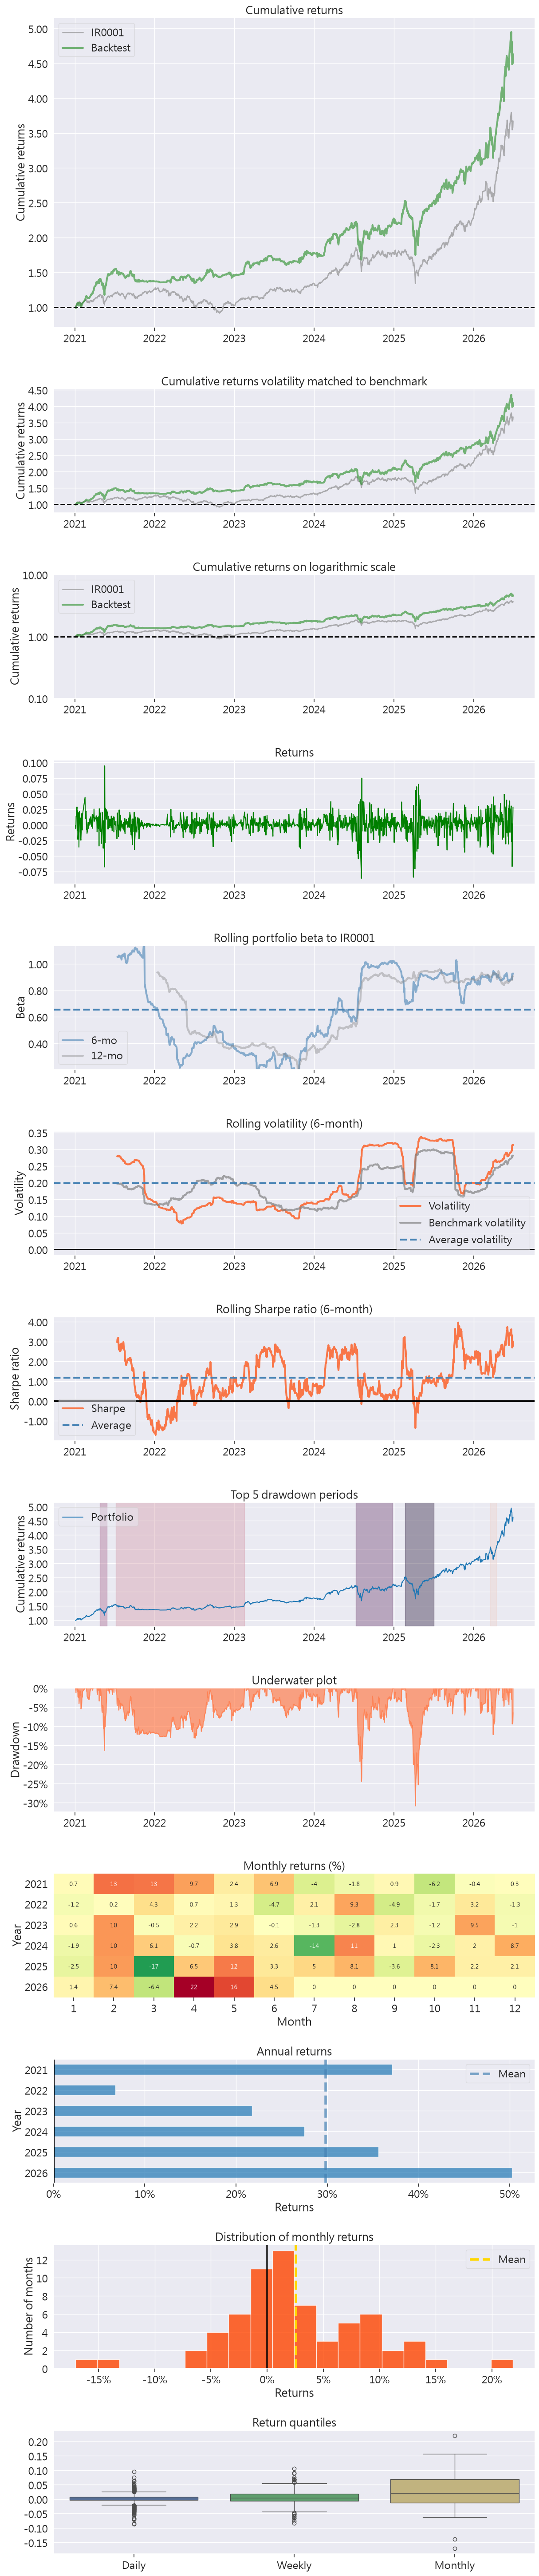

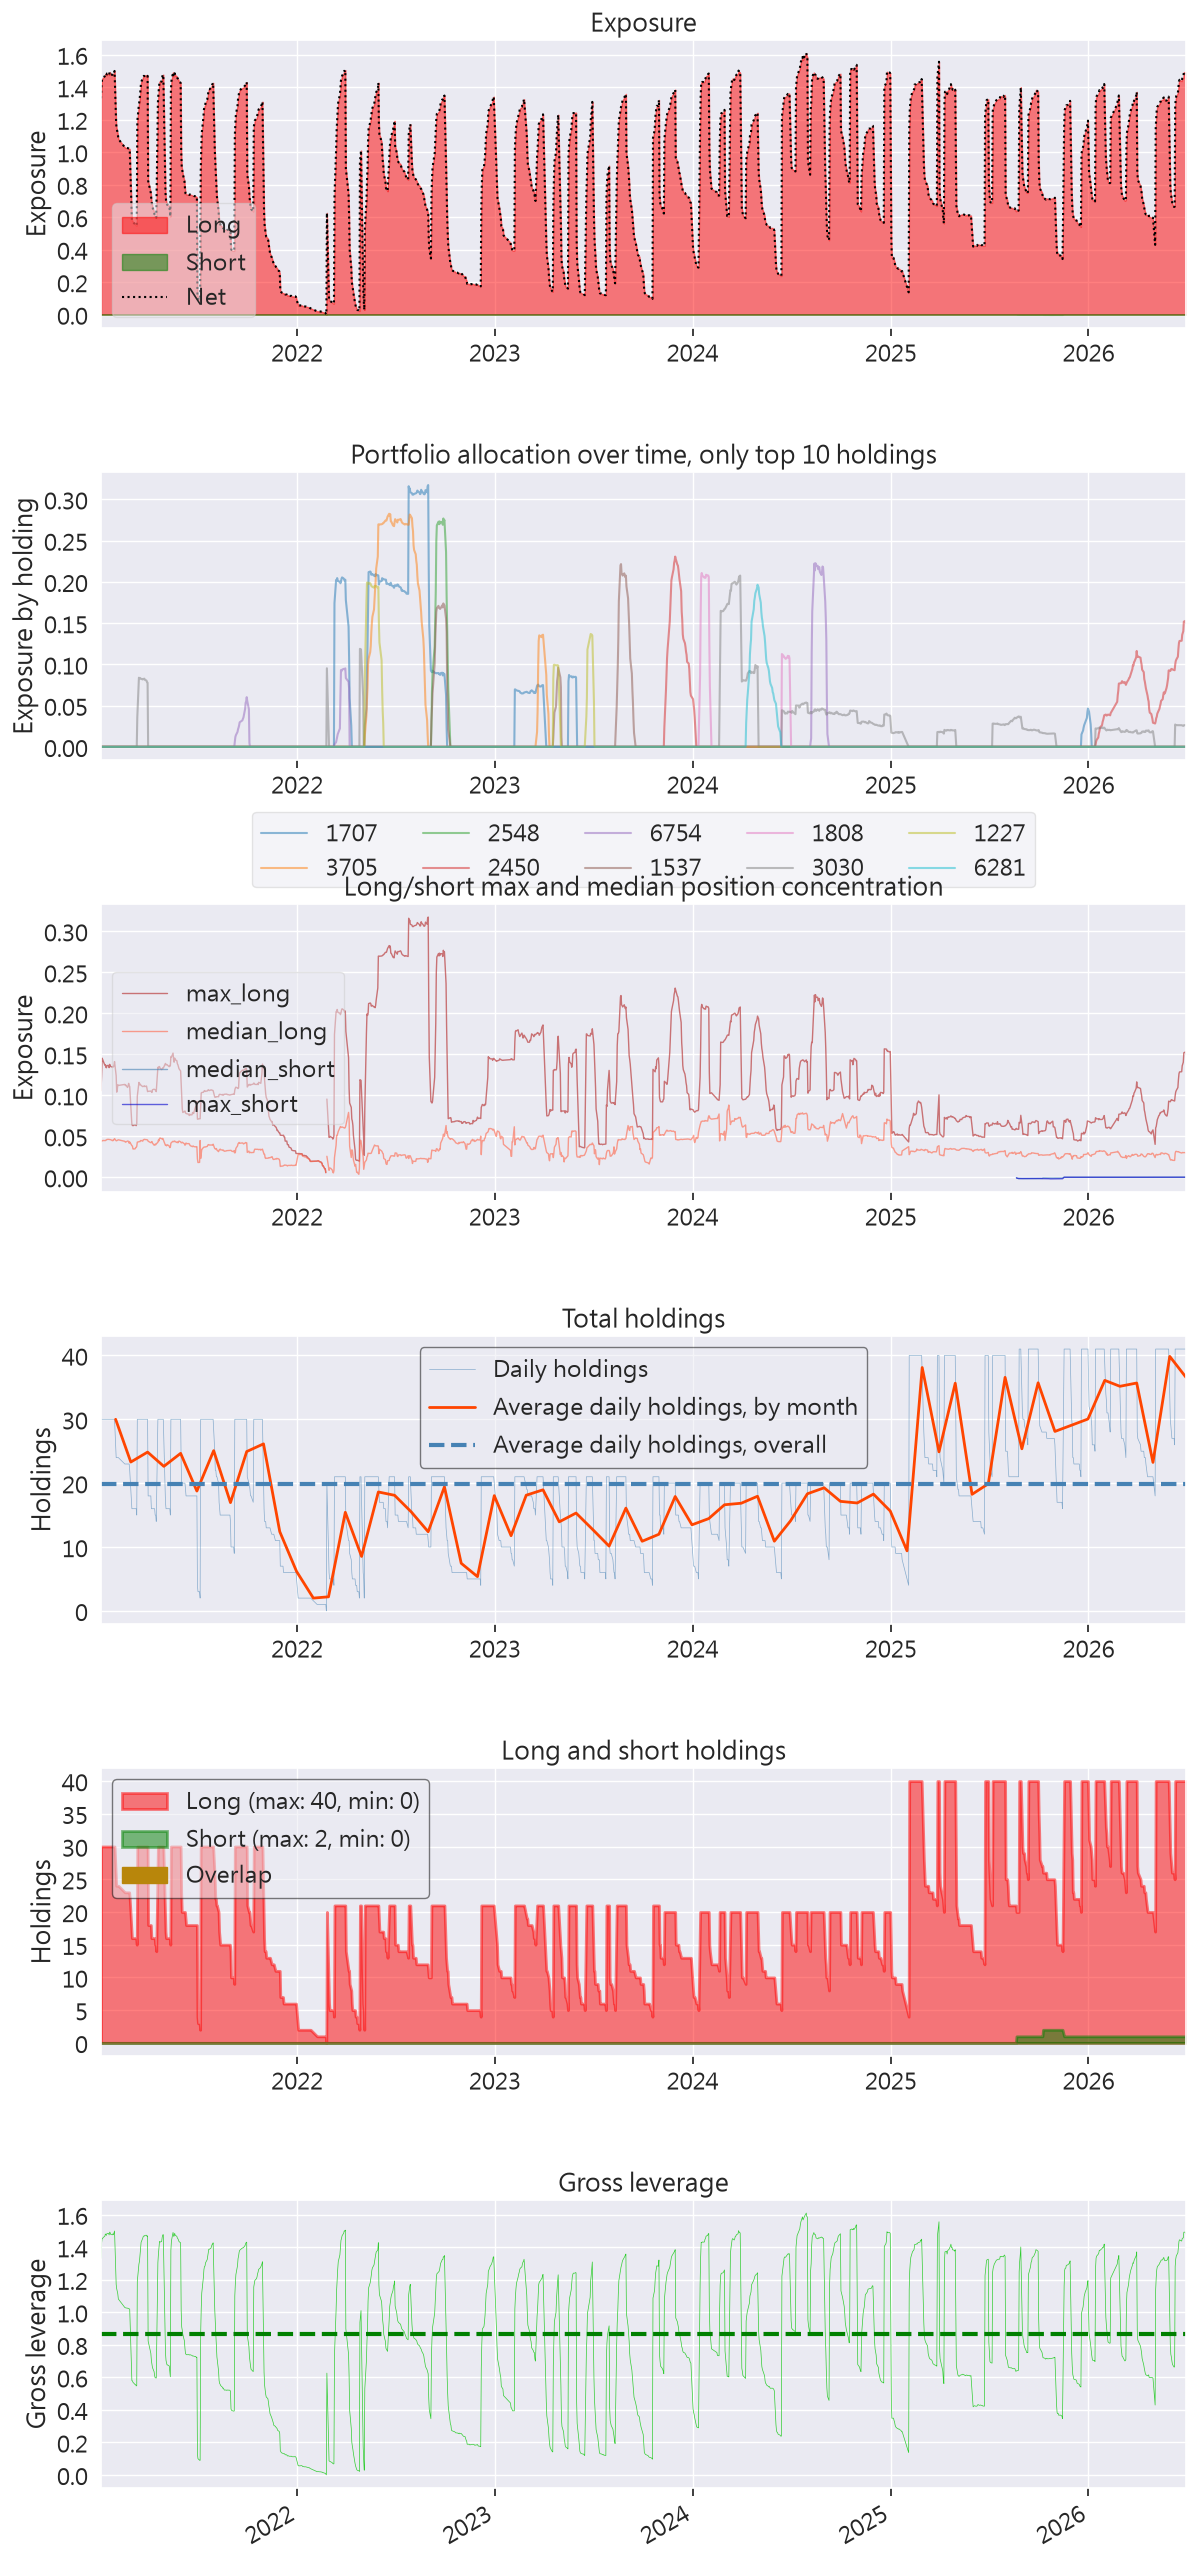

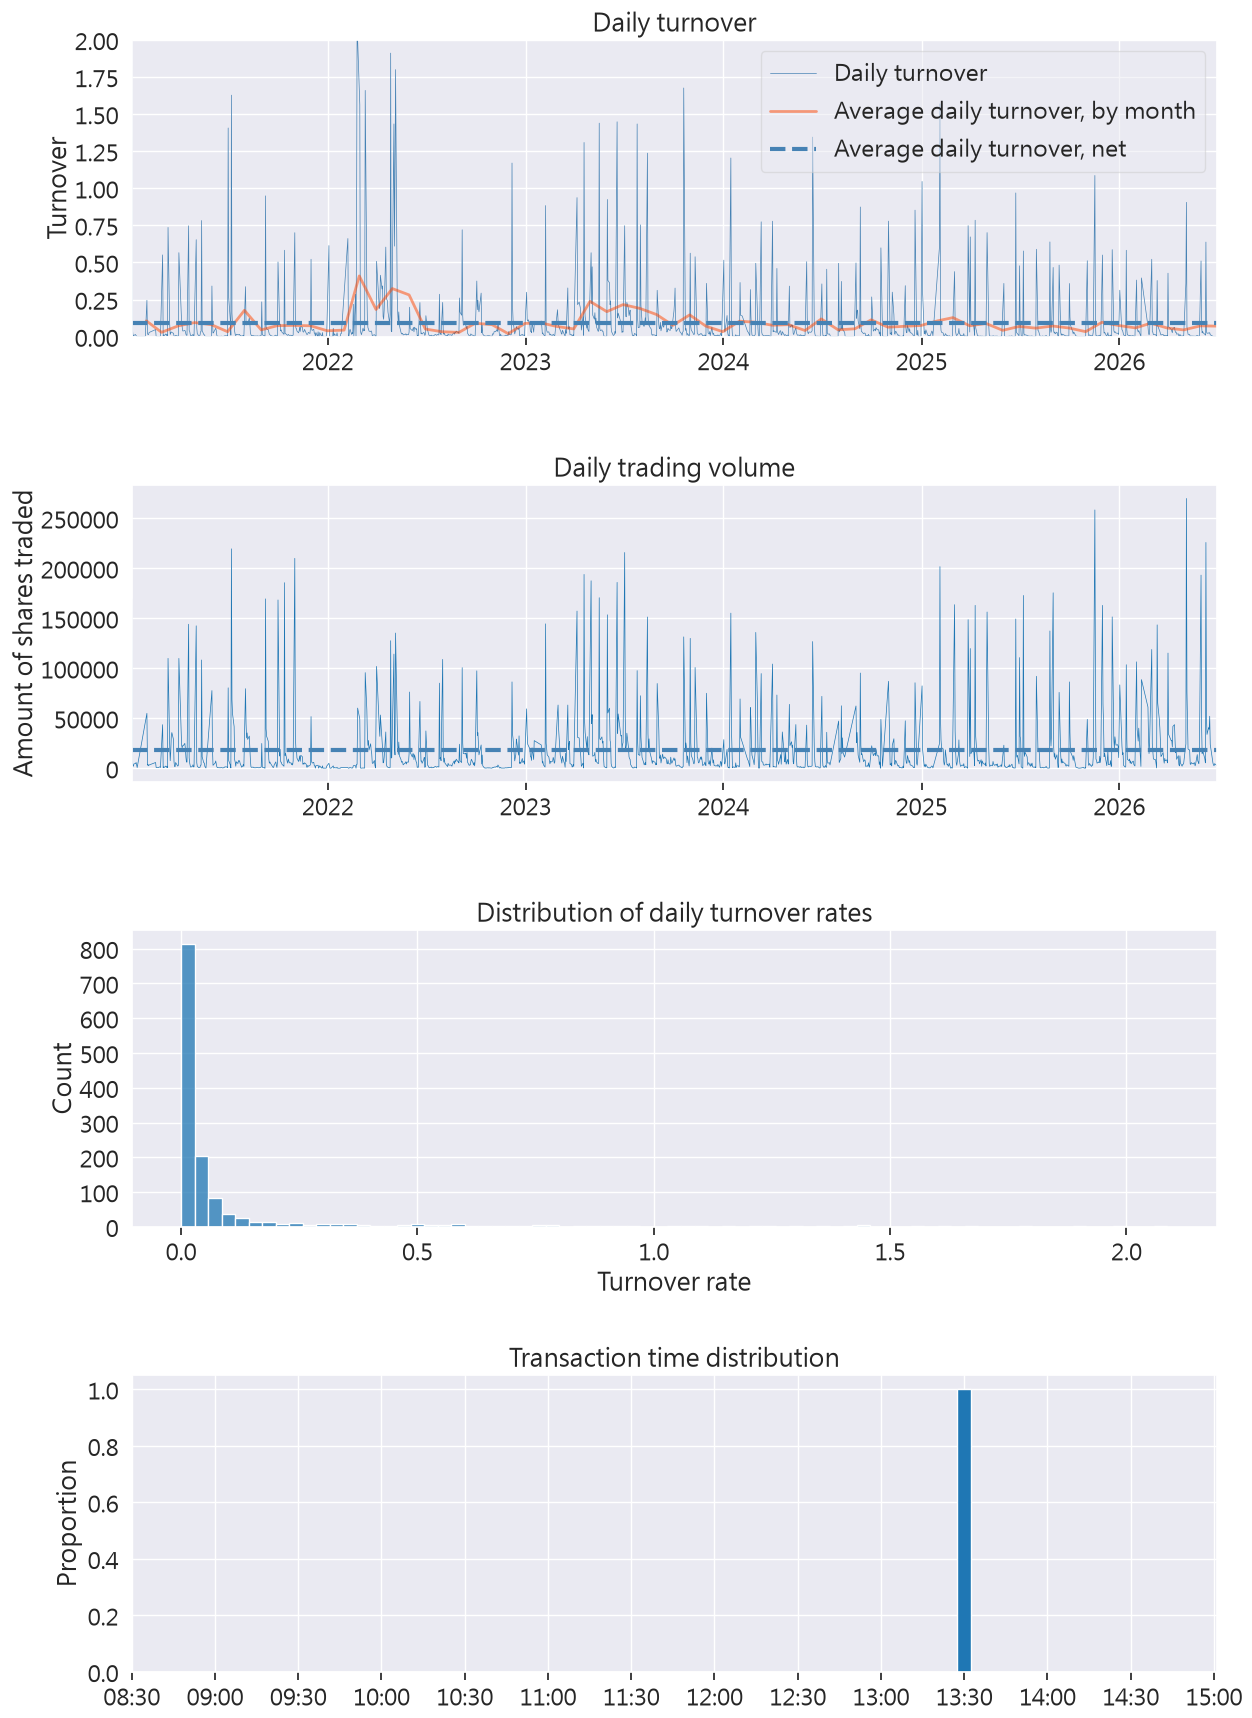

In [50]:
# ── 8-B  Pyfolio 完整 tear sheet ───────────────────────────
pyfolio_header_rows = OrderedDict([
    ('策略', 'IndMom × Quality'),
    ('回測引擎', 'zipline.run_algorithm'),
    ('目標 Gross Leverage', f'{LEVERAGE:.2f}x'),
    ('實際最高 Gross Leverage', f'{observed_max_leverage:.3f}x'),
    ('融資利率假設', f'{ANNUAL_FINANCING_RATE:.2%}'),
])

pyfolio_perf_stats = pf.timeseries.perf_stats(
    pf_returns,
    factor_returns=pf_benchmark_returns,
    positions=pf_positions,
    transactions=pf_transactions,
    turnover_denom='AGB',
)
required_pyfolio_stats = {'Annual return', 'Sharpe ratio', 'Max drawdown'}
missing_pyfolio_stats = required_pyfolio_stats.difference(pyfolio_perf_stats.index)
if missing_pyfolio_stats:
    raise KeyError(f'Pyfolio 核心指標缺少：{sorted(missing_pyfolio_stats)}')
if pyfolio_perf_stats[list(required_pyfolio_stats)].isna().any():
    raise RuntimeError('Pyfolio 核心績效指標含缺值。')

from matplotlib import MatplotlibDeprecationWarning

# pyfolio-tej 2.0.4 在新版 Matplotlib 會產生大量非致命棄用警告；
# 僅限此區塊過濾，其他資料與策略警告仍保留。
with warnings.catch_warnings():
    warnings.simplefilter('ignore', MatplotlibDeprecationWarning)
    warnings.filterwarnings(
        'ignore', category=FutureWarning, module=r'^pyfolio(?:\.|$)'
    )
    pf.create_full_tear_sheet(
        returns=pf_returns,
        positions=pf_positions,
        transactions=pf_transactions,
        benchmark_rets=pf_benchmark_returns,
        estimate_intraday=False,
        round_trips=False,
        bootstrap=False,
        turnover_denom='AGB',
        header_rows=pyfolio_header_rows,
    )
plt.show()